## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/default_models/"
path_to_predictions = pre_path + "predictions/model_B/default_models/"
tag = "Base"
output_parameters = ['T_eff', 'log_g', 'radius']

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


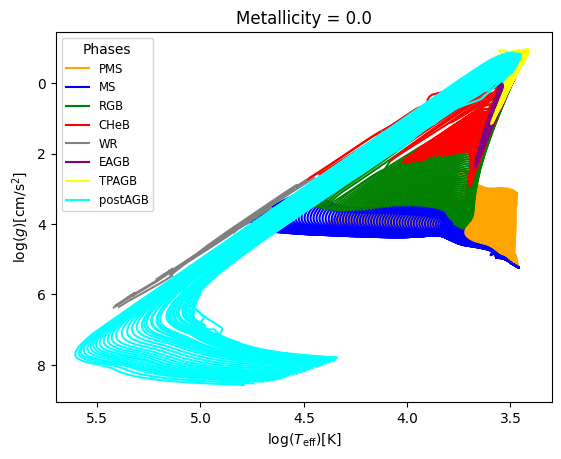

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
1140739,10.3,3.425746,-0.551440,5.0,0.50,0.602856,2.384899
1140740,10.3,3.426469,-0.560350,5.0,0.50,0.598549,2.387797
1140741,10.3,3.427744,-0.566057,5.0,0.50,0.594116,2.389036
1140742,10.3,3.429413,-0.569225,5.0,0.50,0.589648,2.388981


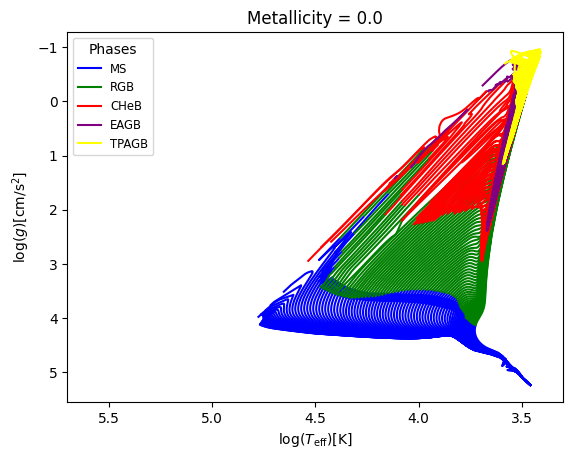

In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3, 4, 5]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [6]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4657, Median : 8.55

log_Teff  : Range : 3.34 - 5.3788, Mean : 3.8298, Median : 3.6739

log_g  : Range : -1.14 - 6.2594, Mean : 2.0665, Median : 2.005

Values in phase column : 0.0, 2.0, 3.0, 4.0, 5.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 7.5368, Median : 2.0818

log_R  : Range : -1.0 - 3.1298, Mean : 1.3949, Median : 1.5001



In [7]:
X_train, X_ivs, y_train, y_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 5.378675973625695
Median value in train data for the log_Teff parameter: 3.6737679778938226
Mean value in train data for the log_Teff parameter: 3.829879593824312

Range in train data for the log_g parameter : -1.14489780699774 - 6.259434356871683
Median value in train data for the log_g parameter: 2.007777137067153
Mean value in train data for the log_g parameter: 2.067468513515282

Range in train data for the log_R parameter : -0.9974747647513328 - 3.129269620812593
Median value in train data for the log_R parameter: 1.4993114860984695
Mean value in train data for the log_R parameter: 1.3944707591667809

Testing set statistics:
Range in test data for the log_Teff parameter : 3.3446822240585243 - 5.378801600728572
Median value in test data for the log_Teff parameter: 3.674156503315524
Mean value in test data for the log_Teff parameter: 3.8296077112173066

Range in test data for the log_g para

## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.6076992893351689
RMSE :  0.21793271210403106
MAE :  0.18221130705950903
MedAE :  0.17309933303549507
CORR :  0.7795506971201598
MAX_ER :  1.1164278436408308
Percentiles : 
  75th percentile :  0.281849927889406
  90th percentile :  0.33888477870225553
  95th percentile :  0.36378756510875027
  99th percentile :  0.4538558780382052



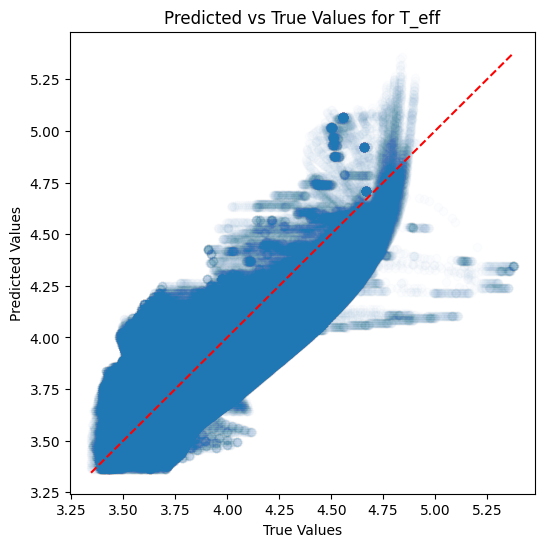

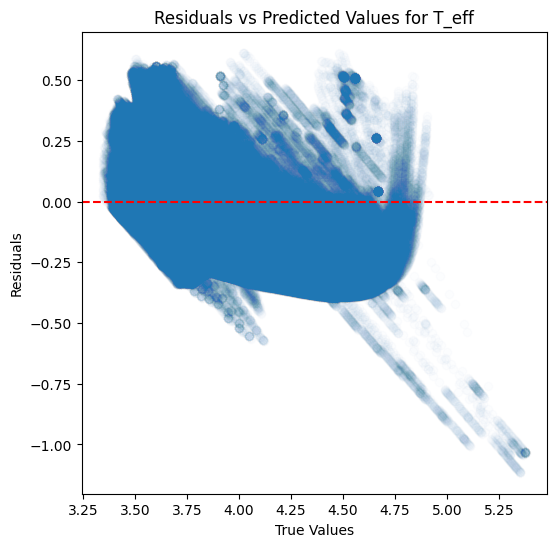

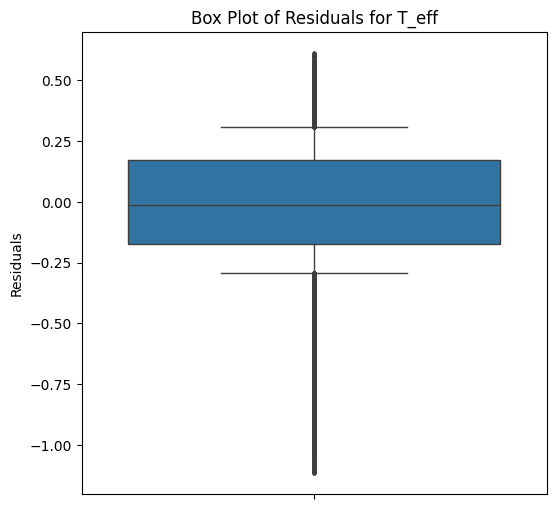

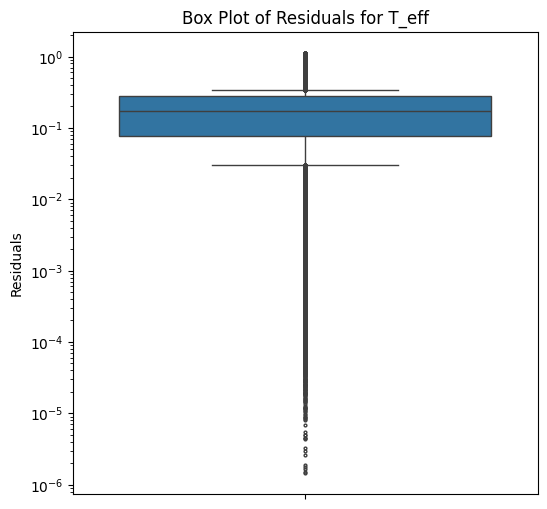

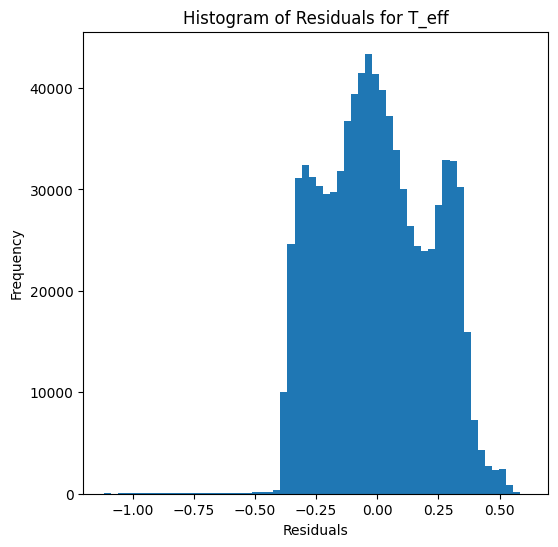

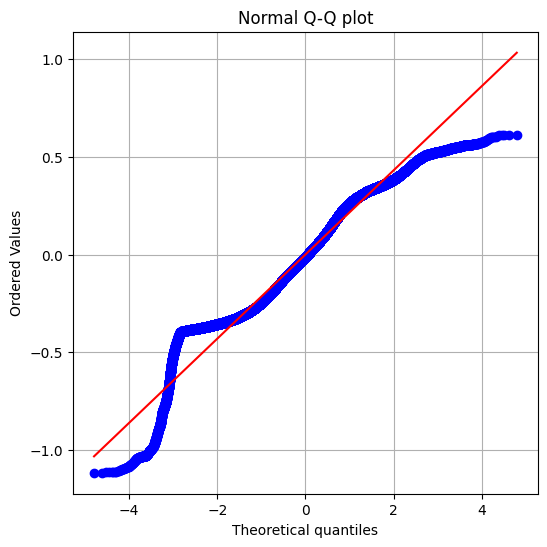


log_g results:
RVE :  0.12415327029075451
RMSE :  1.7828668487059218
MAE :  1.5467953811599233
MedAE :  1.4404332308466172
CORR :  0.35235389925763627
MAX_ER :  4.387659091389643
Percentiles : 
  75th percentile :  2.2326353602917584
  90th percentile :  2.71868053568366
  95th percentile :  3.049417280228647
  99th percentile :  3.7154509399367437



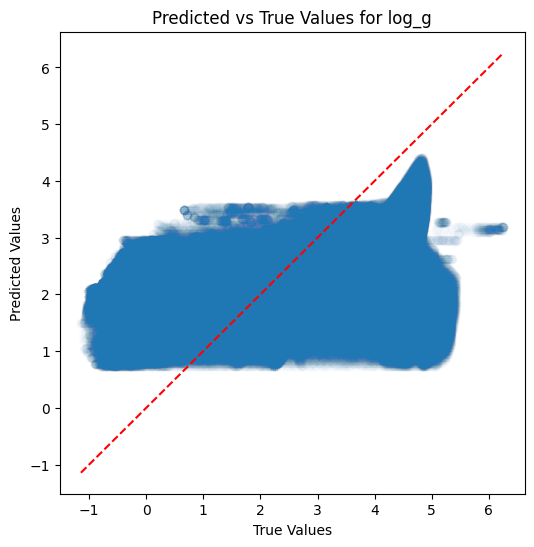

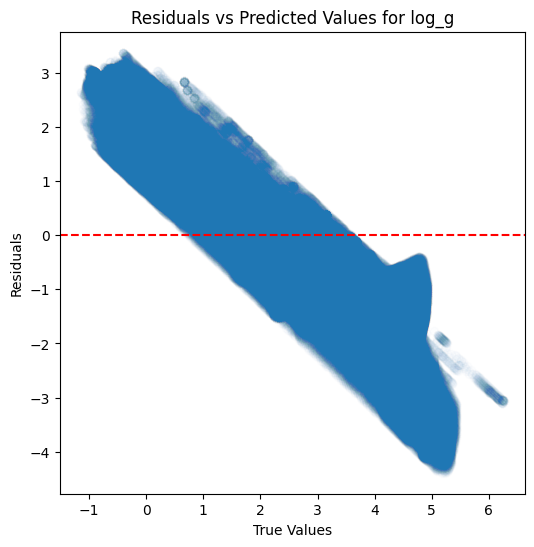

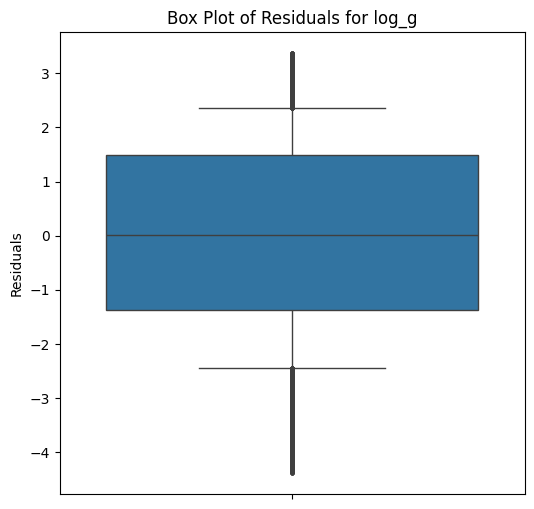

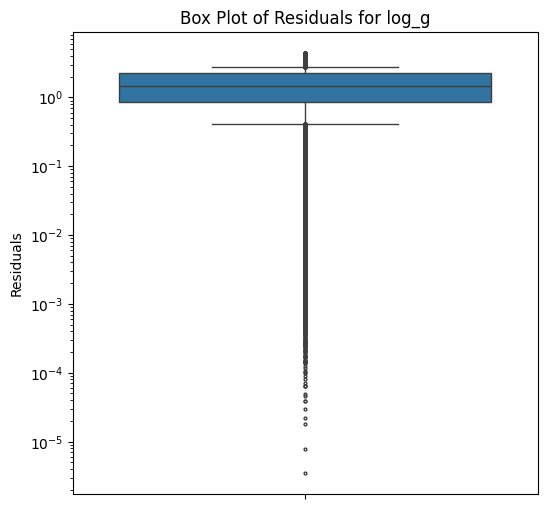

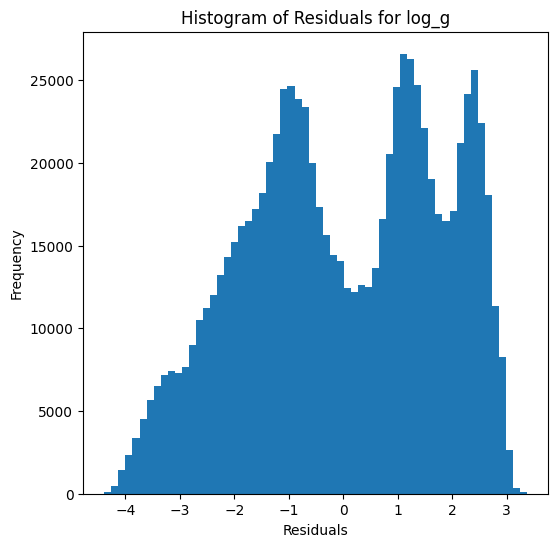

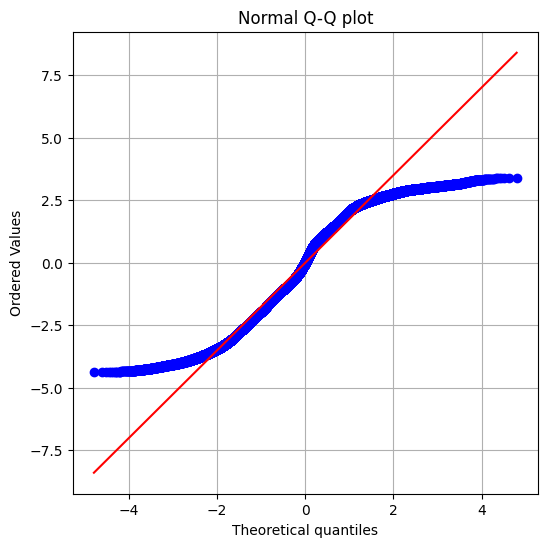


radius results:
RVE :  0.03857323153903791
RMSE :  0.9319771834474598
MAE :  0.7990249166151603
MedAE :  0.7439515433609396
CORR :  0.19640069205138172
MAX_ER :  2.5913426684529366
Percentiles : 
  75th percentile :  1.1541241297392568
  90th percentile :  1.3650698136677888
  95th percentile :  1.648420616230986
  99th percentile :  2.1308606297073256



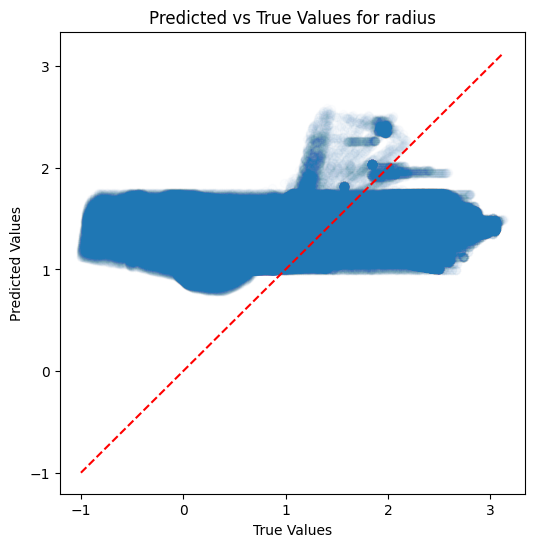

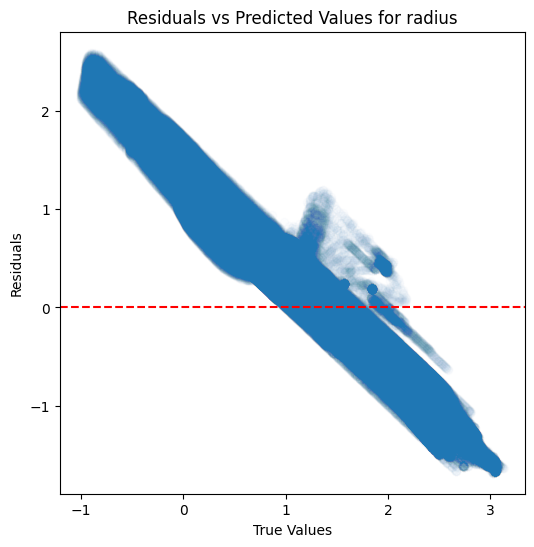

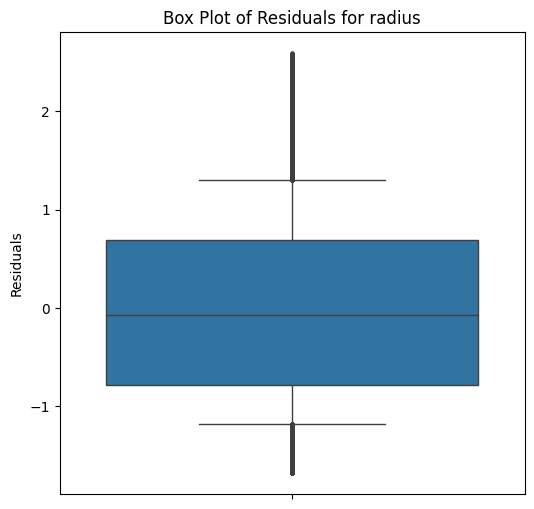

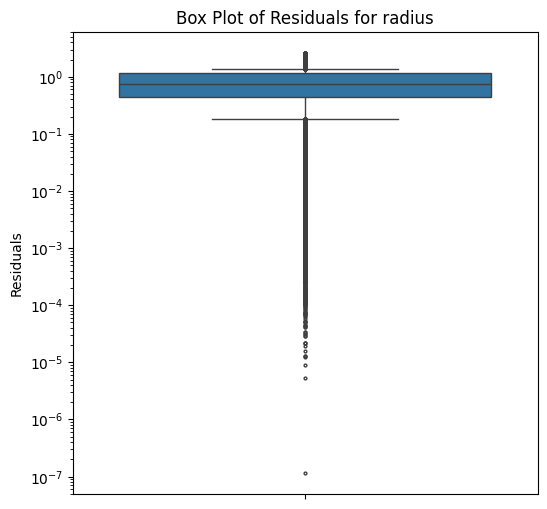

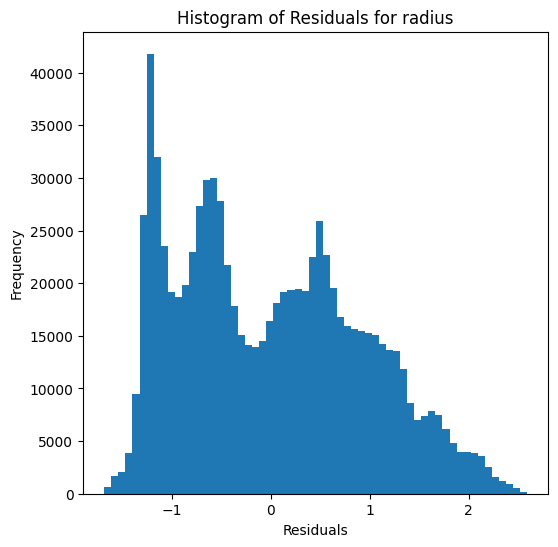

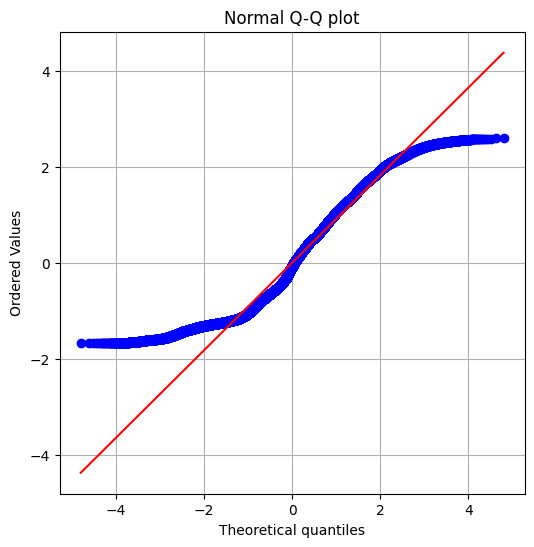

In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False) #, override=False, use_preds=True)

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.7452583163609888
RMSE :  0.1756158001541517
MAE :  0.07297509875362443
MedAE :  0.0022322118814637193
CORR :  0.8726207548915489
MAX_ER :  0.9649891692791774
Percentiles : 
  75th percentile :  0.02035293550648254
  90th percentile :  0.31523290649108904
  95th percentile :  0.49768885308389427
  99th percentile :  0.657947568412684



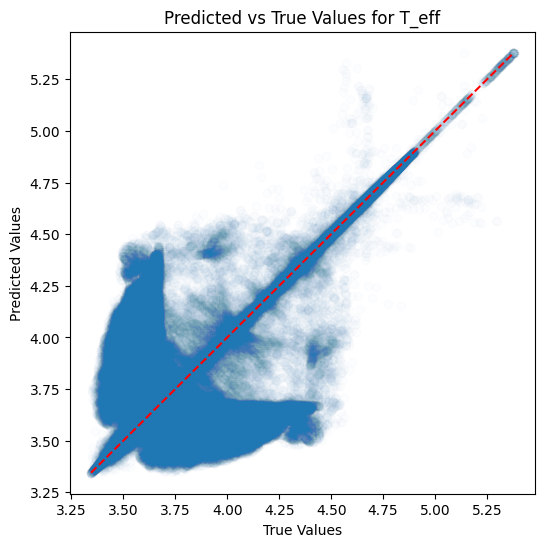

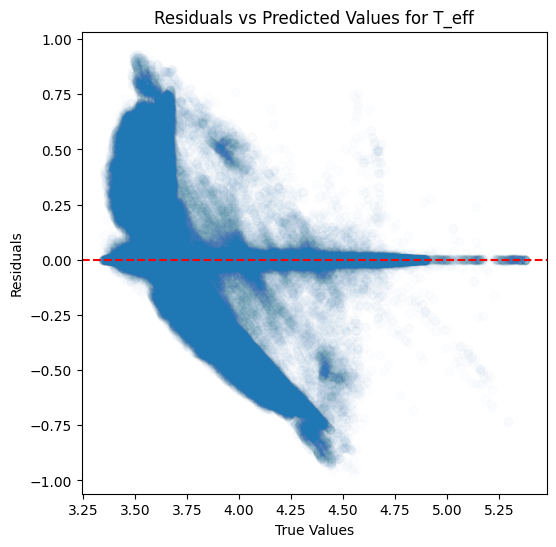

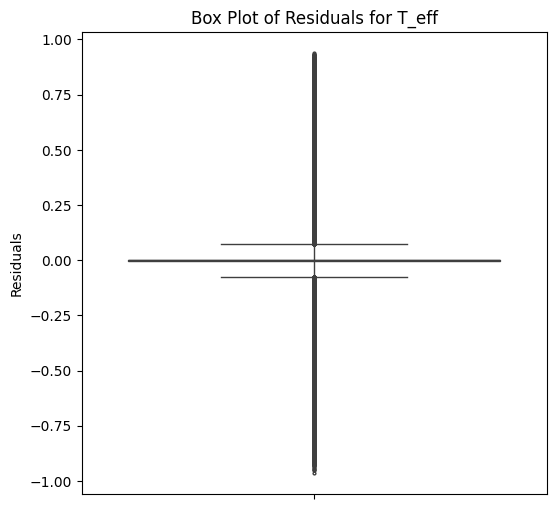

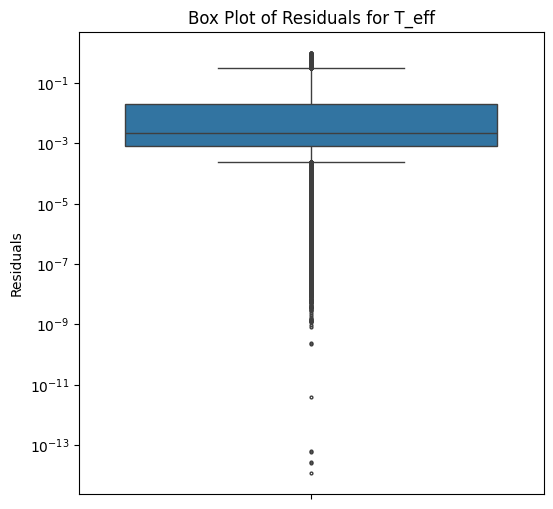

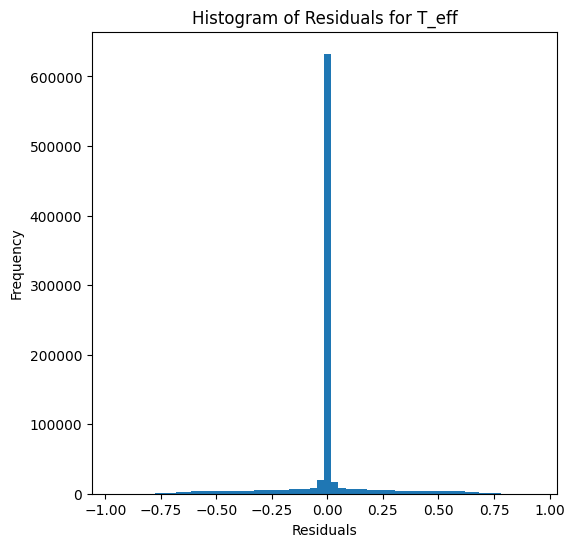

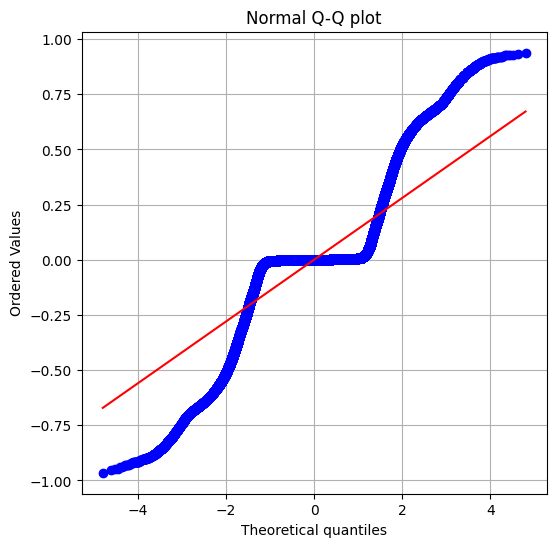


log_g results:
RVE :  0.24547994256397088
RMSE :  1.6547848321602954
MAE :  0.7290359622603714
MedAE :  0.016071256420864904
CORR :  0.6228019633841714
MAX_ER :  5.670130910163134
Percentiles : 
  75th percentile :  0.19152989093671388
  90th percentile :  3.819592631783121
  95th percentile :  4.587516502110694
  99th percentile :  5.149753991297566



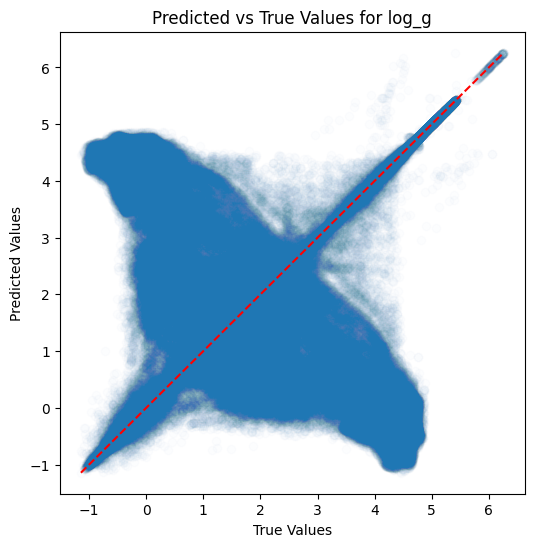

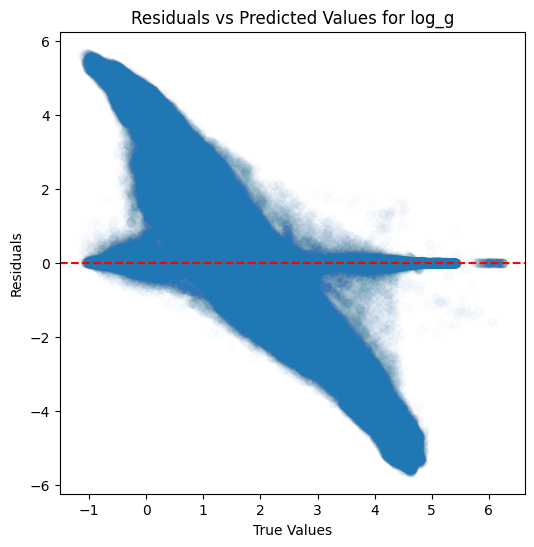

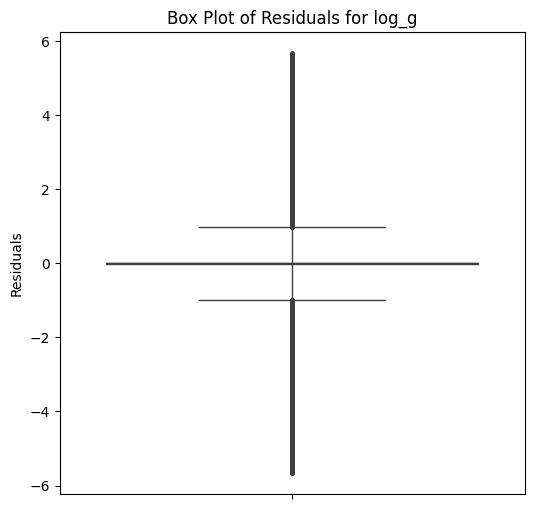

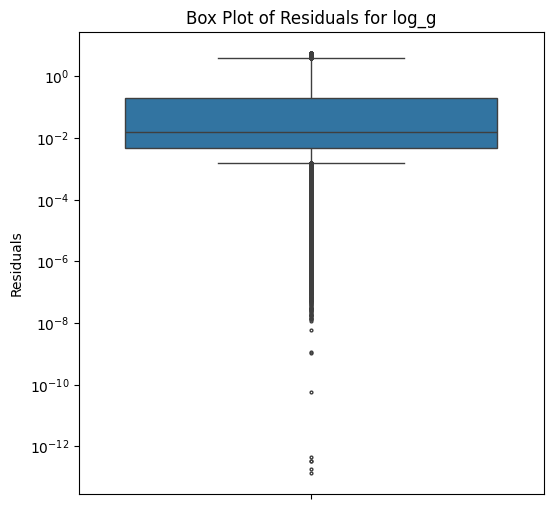

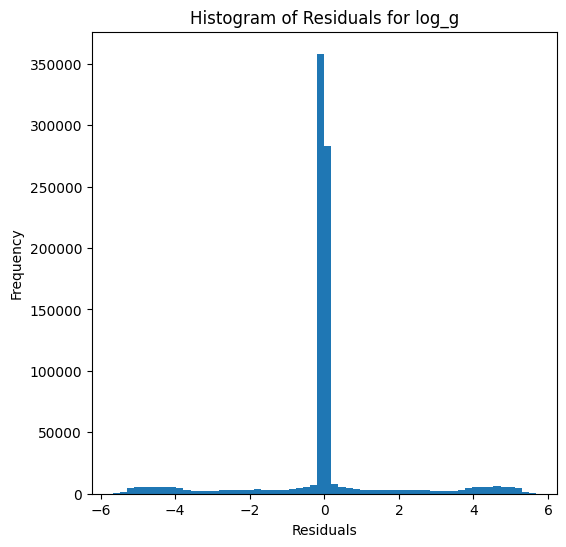

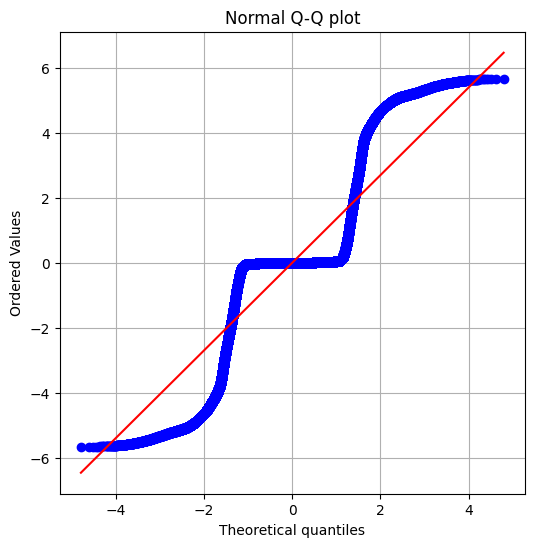


radius results:
RVE :  0.24220016480163686
RMSE :  0.8274193872431967
MAE :  0.36478259101651617
MedAE :  0.008360457709404523
CORR :  0.6214450664706042
MAX_ER :  2.834585462209228
Percentiles : 
  75th percentile :  0.09614734562156124
  90th percentile :  1.9098156023794772
  95th percentile :  2.2925199831055165
  99th percentile :  2.5760122689175455



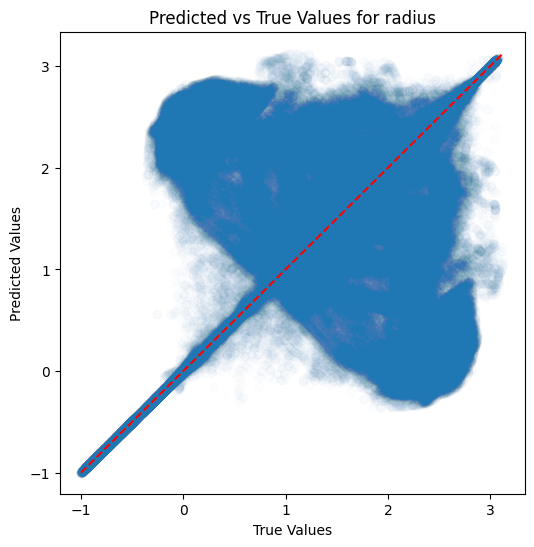

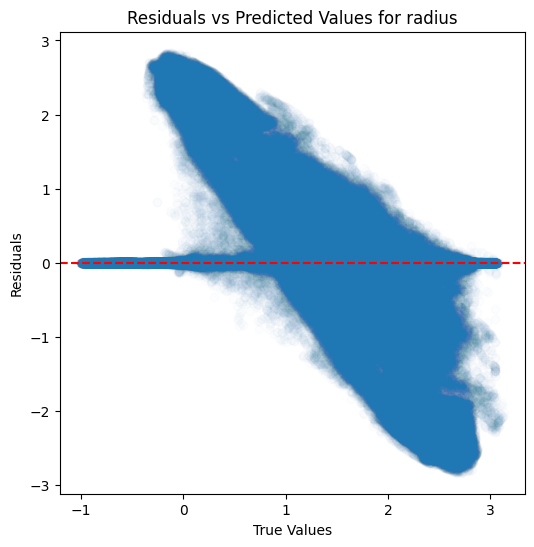

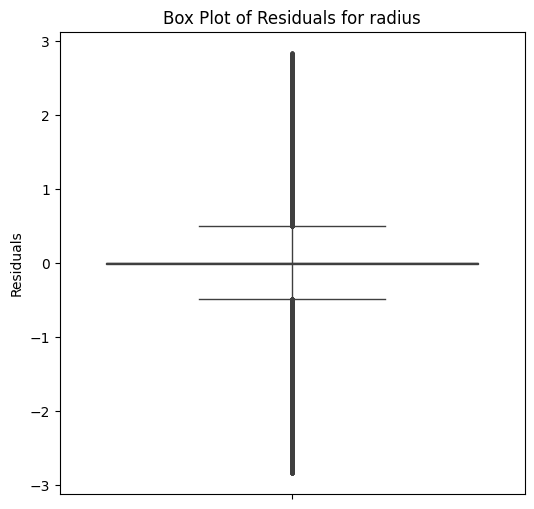

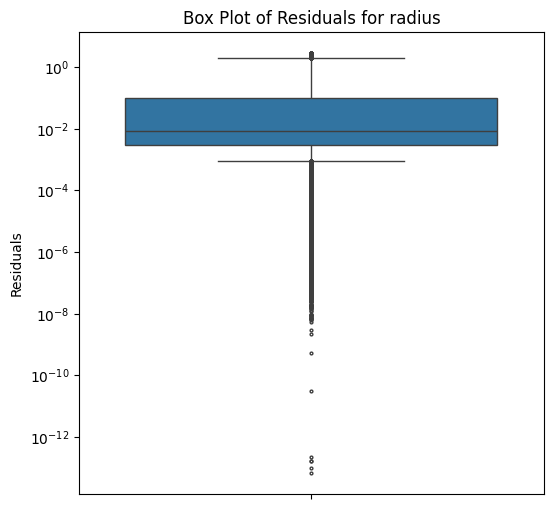

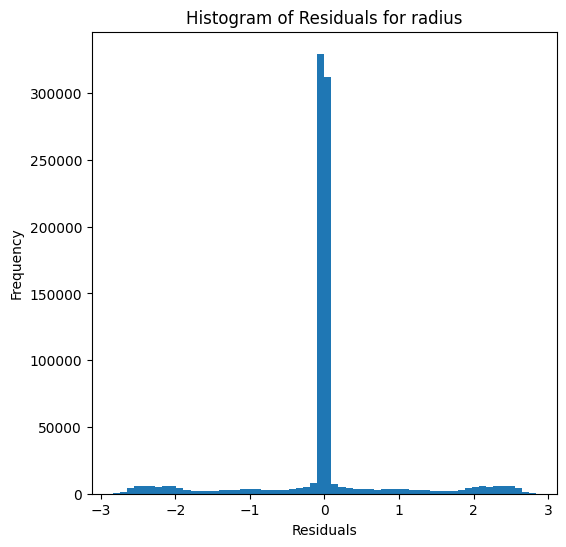

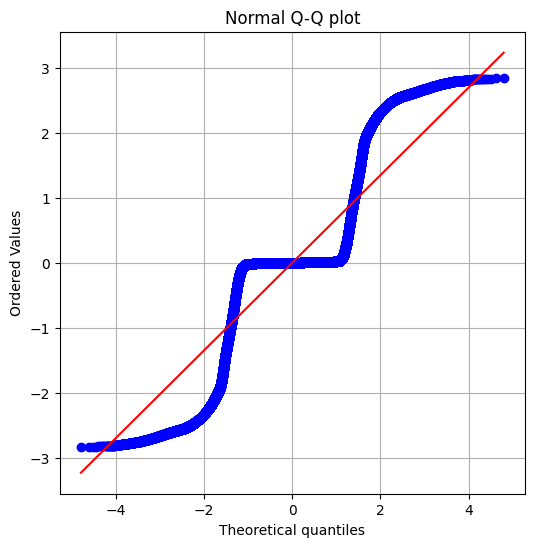

In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False) #, override=False, use_preds=True)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.8686709334430261
RMSE :  0.12619714204815877
MAE :  0.059428499535101396
MedAE :  0.004564334487184407
CORR :  0.9322914127625772
MAX_ER :  0.977850711824563
Percentiles : 
  75th percentile :  0.07380439618140633
  90th percentile :  0.18673910315904815
  95th percentile :  0.29598037020827905
  99th percentile :  0.552333694323516



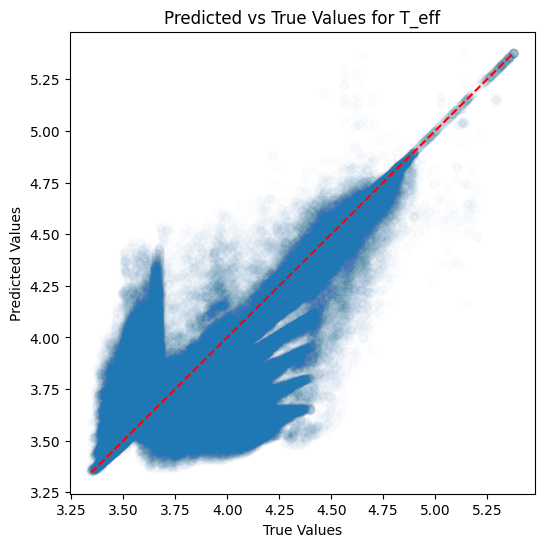

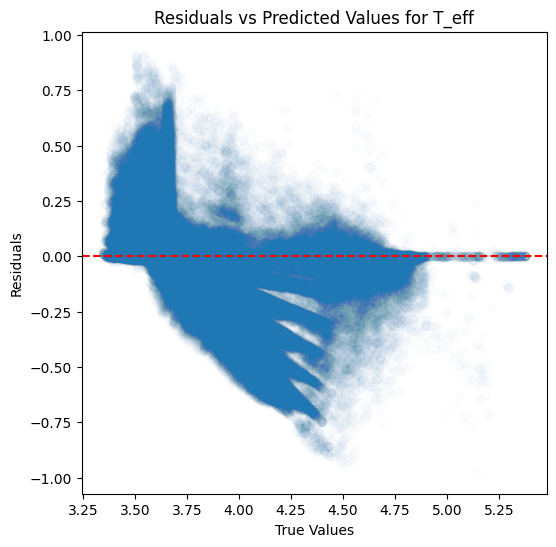

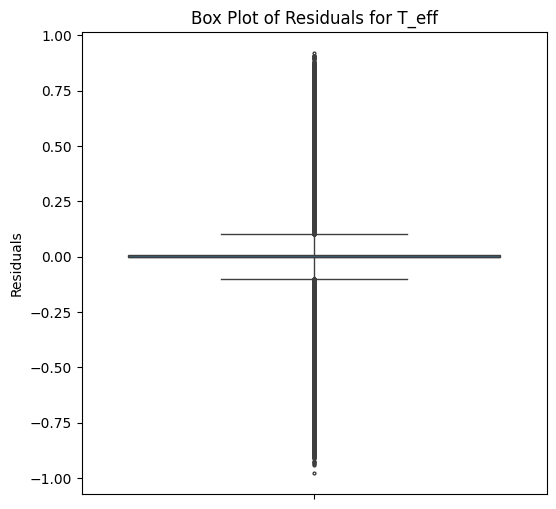

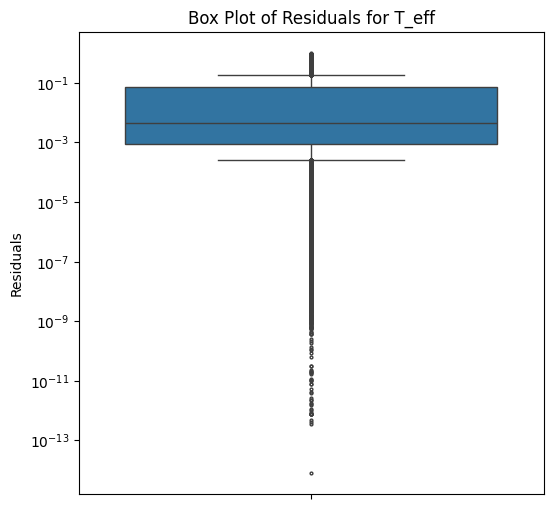

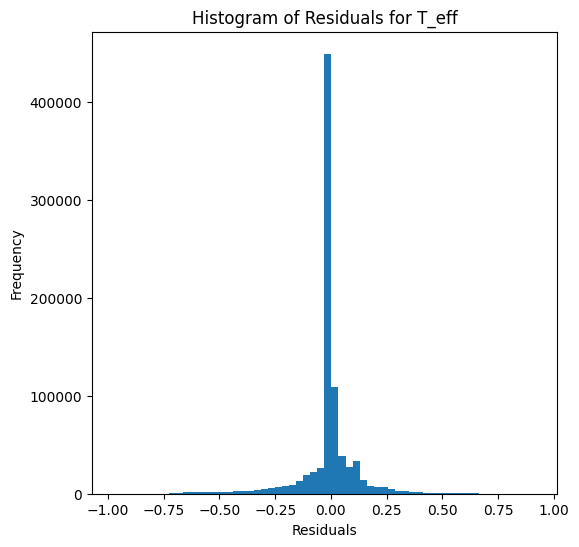

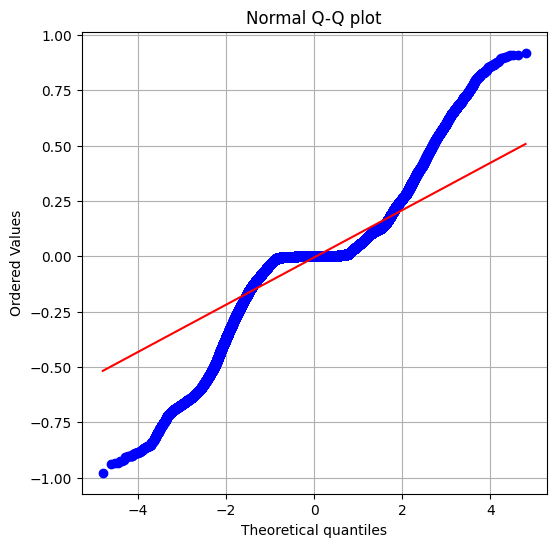


log_g results:
RVE :  0.624533114745166
RMSE :  1.1682709244172818
MAE :  0.5807103542179328
MedAE :  0.03804983534788542
CORR :  0.7942729571033528
MAX_ER :  5.6681994560339515
Percentiles : 
  75th percentile :  0.8359454648730515
  90th percentile :  1.9135460221910852
  95th percentile :  2.988644378198292
  99th percentile :  4.625439294740223



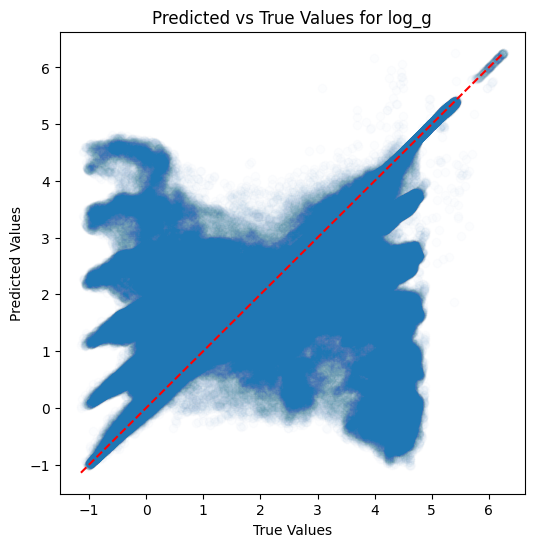

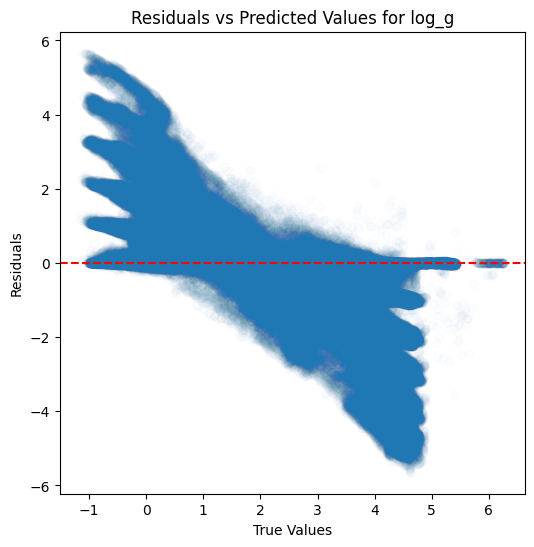

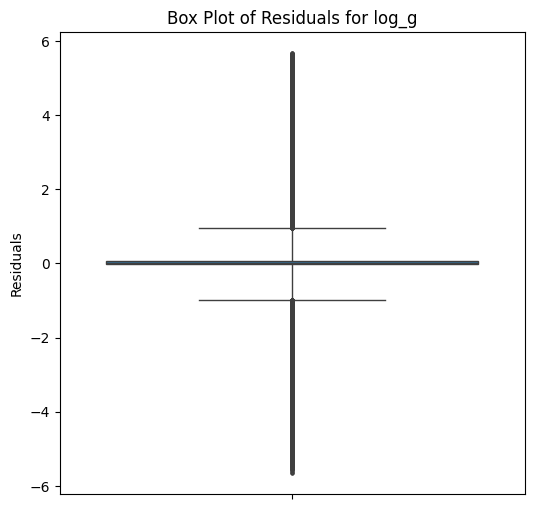

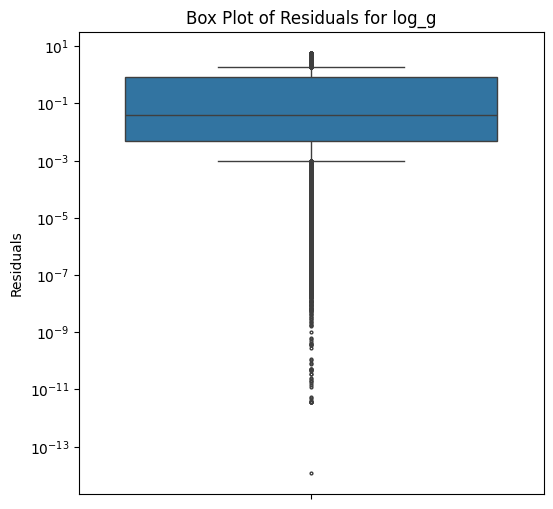

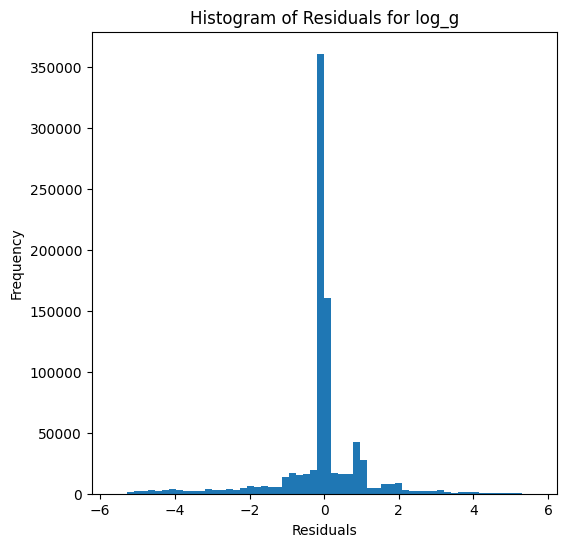

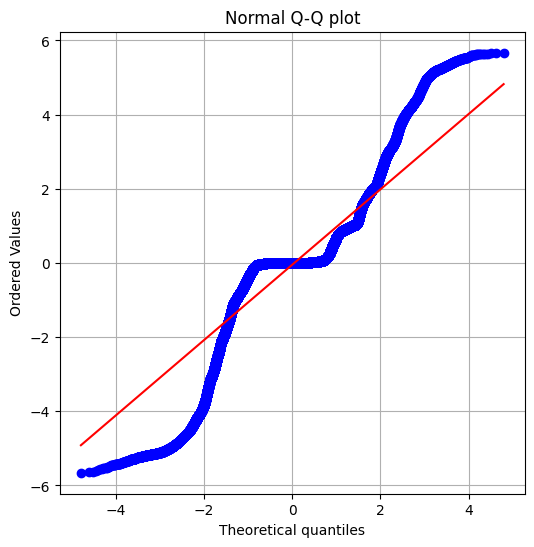


radius results:
RVE :  0.6228895668715246
RMSE :  0.5841636396995514
MAE :  0.290655388239903
MedAE :  0.019865249656891237
CORR :  0.7932244166644536
MAX_ER :  2.8331221942229985
Percentiles : 
  75th percentile :  0.4179642556601687
  90th percentile :  0.9568444199746048
  95th percentile :  1.4940449620652752
  99th percentile :  2.3110092246111047



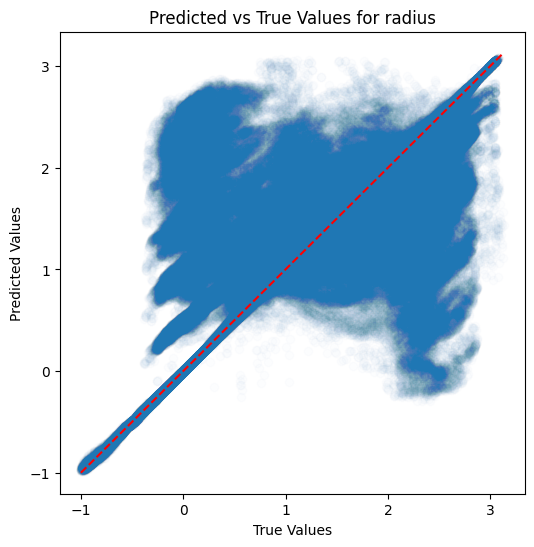

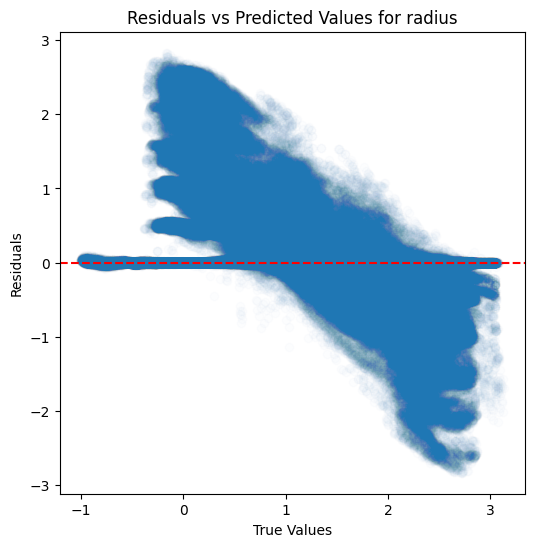

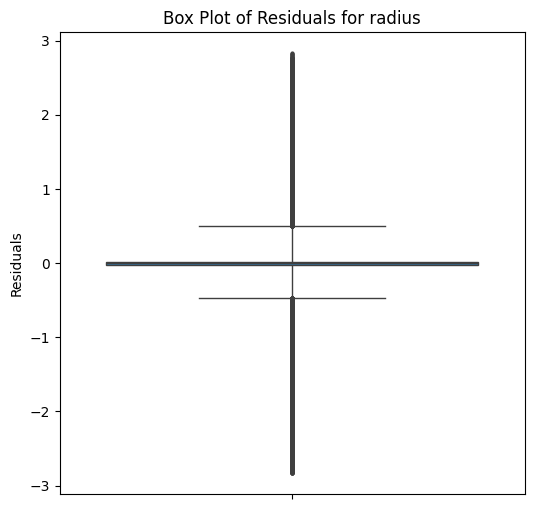

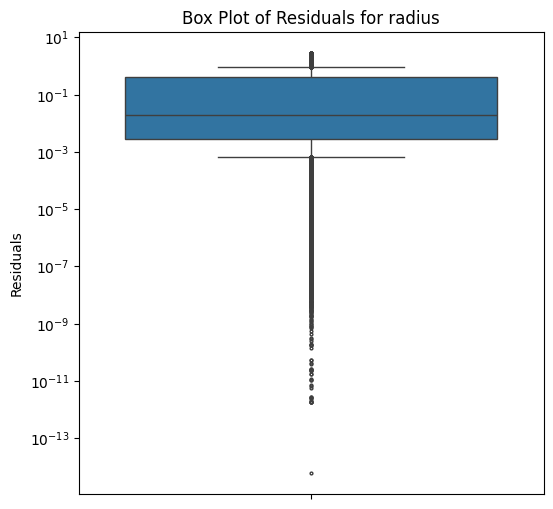

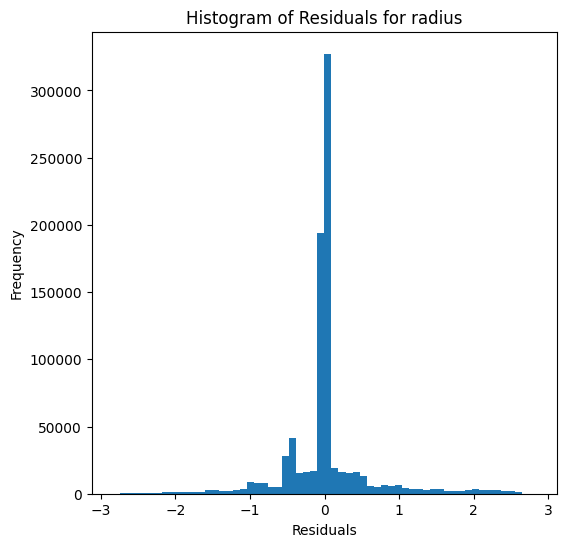

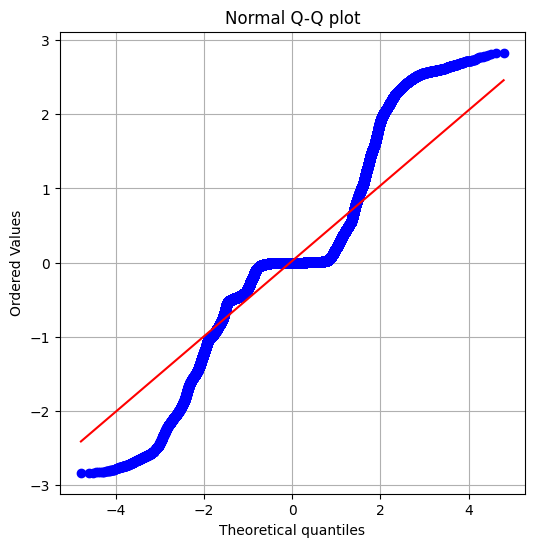

In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False) #, override=False, use_preds=True)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.8405676374048032
RMSE :  0.13893291351799592
MAE :  0.0659477969975966
MedAE :  0.004957429928773793
CORR :  0.9178345309926252
MAX_ER :  0.9185678232000773
Percentiles : 
  75th percentile :  0.07243621422301016
  90th percentile :  0.23281686634376705
  95th percentile :  0.3501279934328738
  99th percentile :  0.5578533633169838



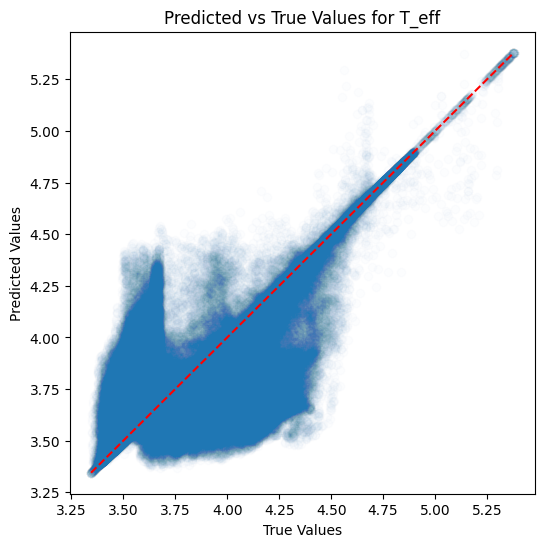

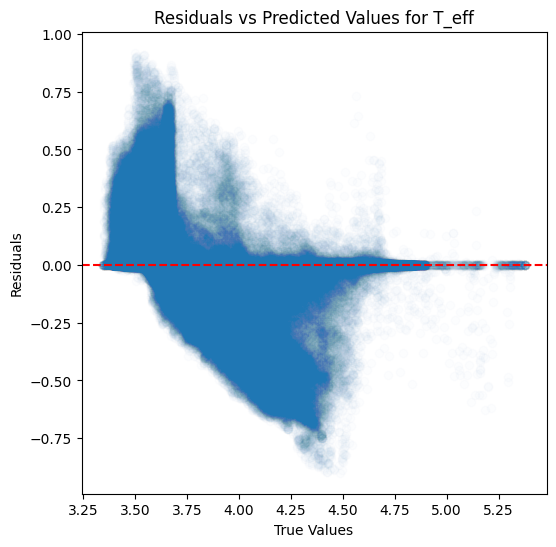

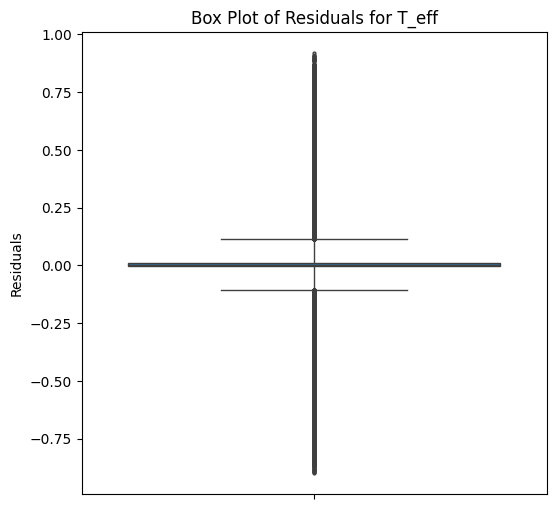

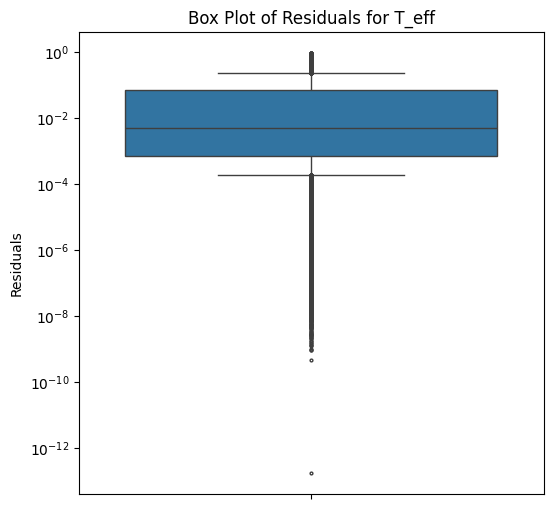

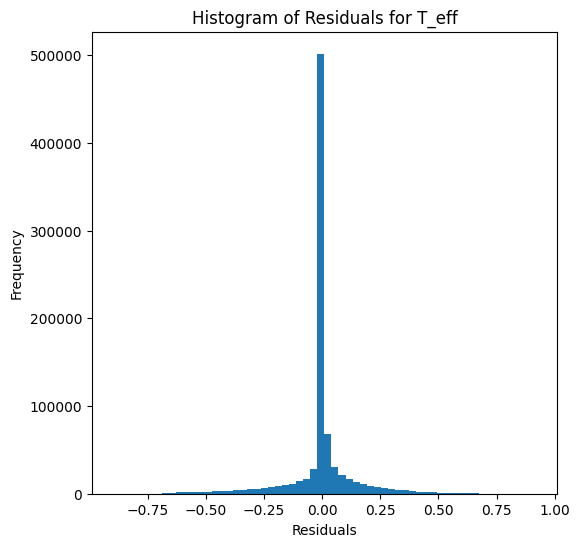

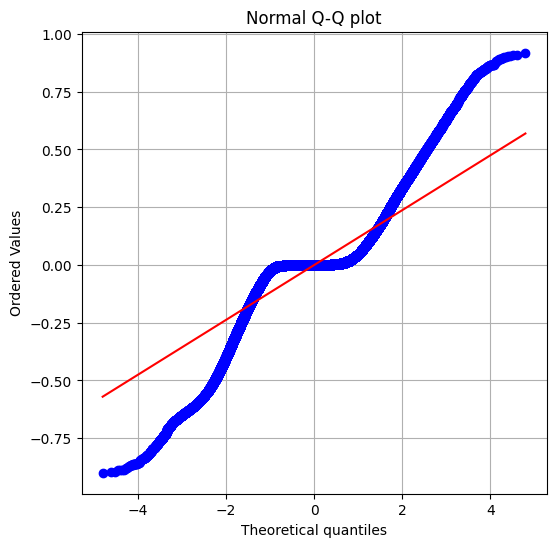


log_g results:
RVE :  0.5313307782609096
RMSE :  1.3042021357563842
MAE :  0.6641833875192797
MedAE :  0.04430840060808991
CORR :  0.7410645867263336
MAX_ER :  5.669559545289839
Percentiles : 
  75th percentile :  0.850341409374952
  90th percentile :  2.477665460566655
  95th percentile :  3.359846774898085
  99th percentile :  4.509917081425346



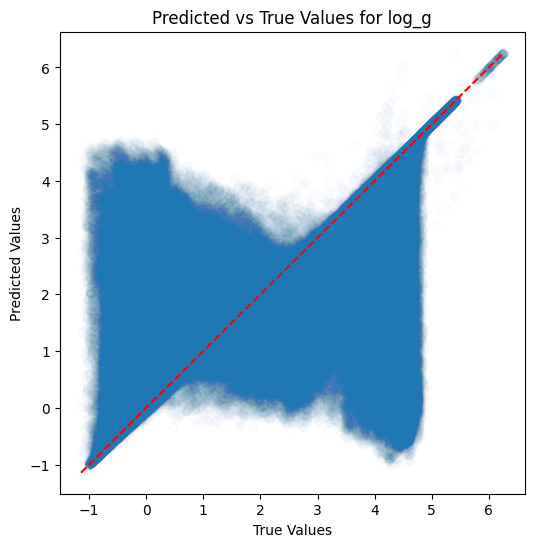

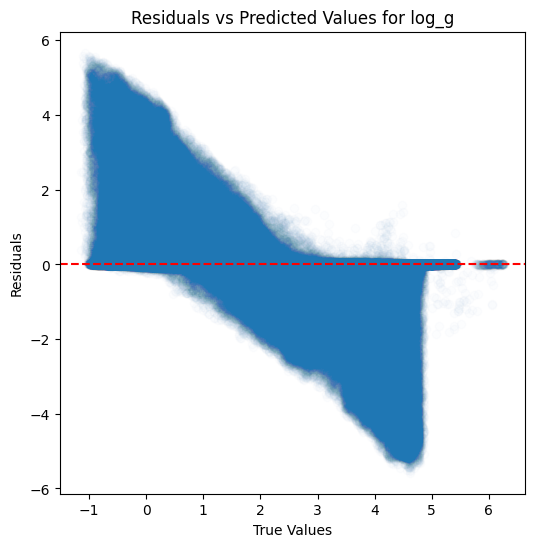

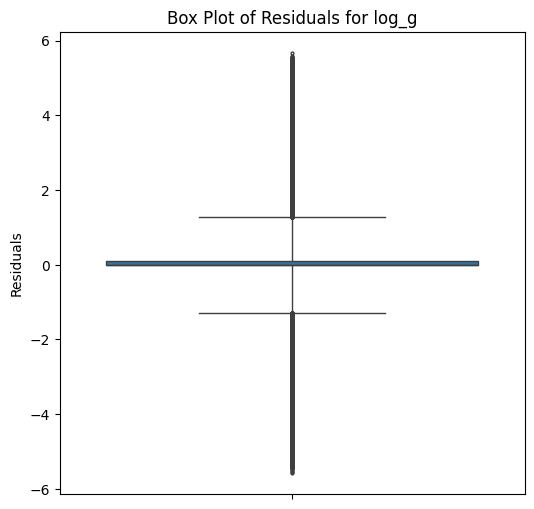

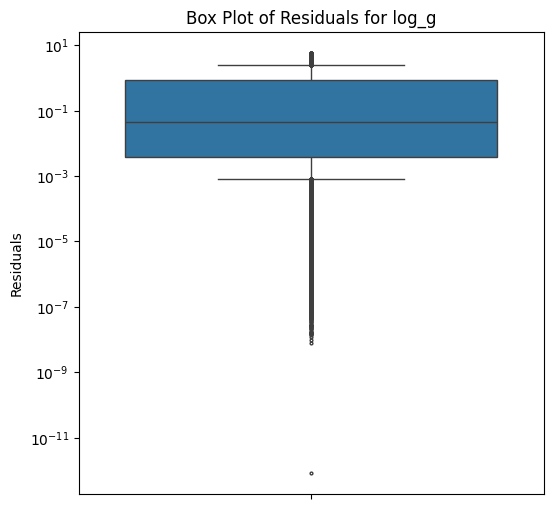

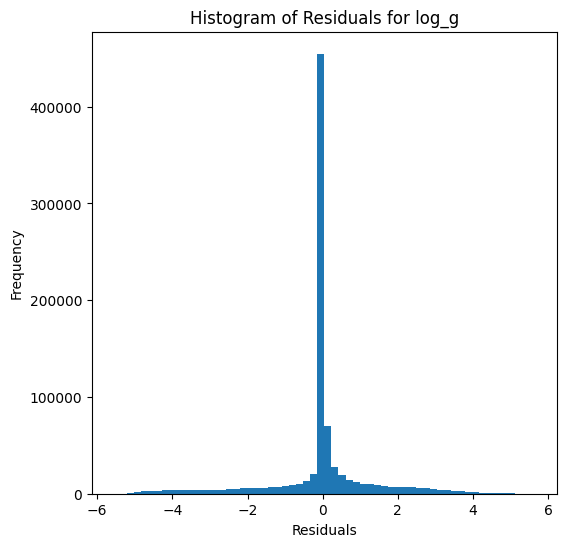

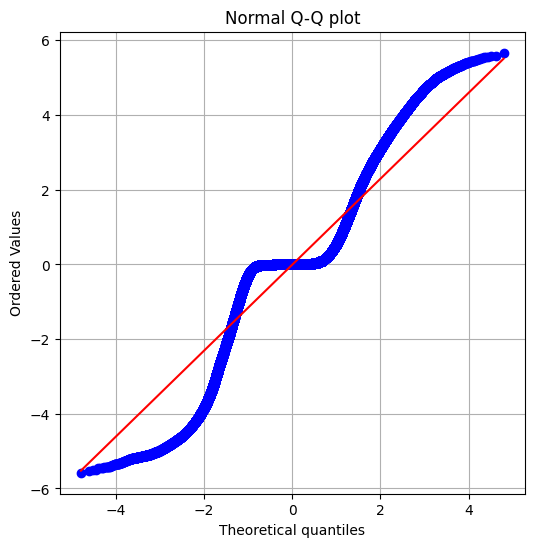


radius results:
RVE :  0.529293998161159
RMSE :  0.6521221246960388
MAE :  0.3321843969792346
MedAE :  0.02221510969498941
CORR :  0.7397699321684901
MAX_ER :  2.8347375799392576
Percentiles : 
  75th percentile :  0.42522292618544266
  90th percentile :  1.2389199609517527
  95th percentile :  1.6802265161399832
  99th percentile :  2.2548764408280886



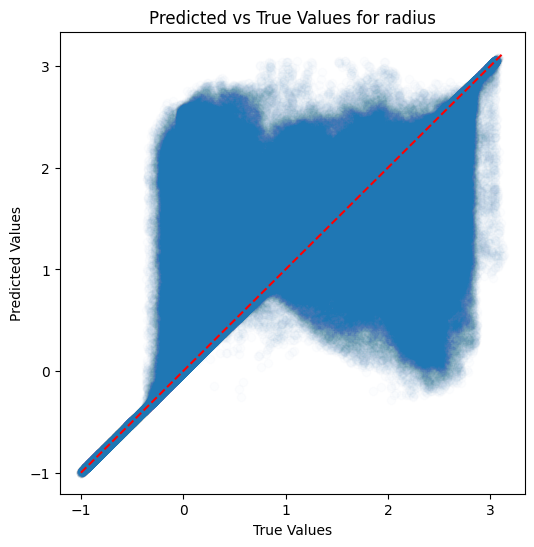

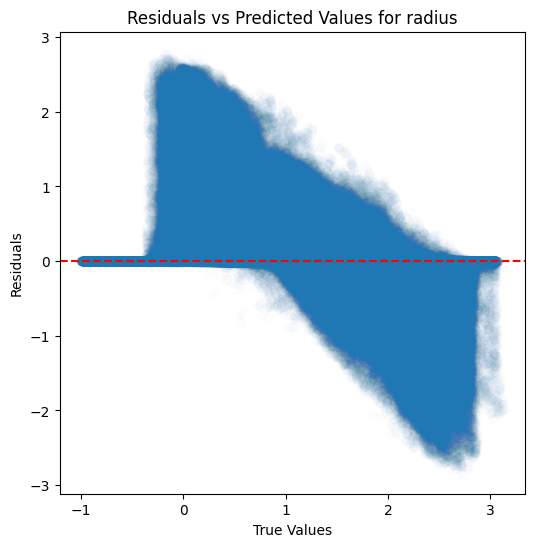

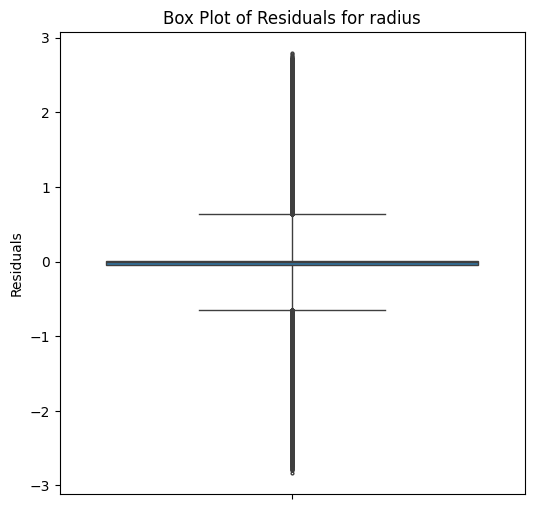

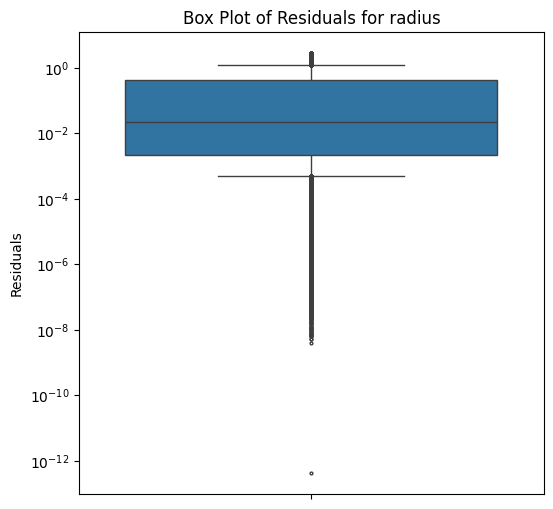

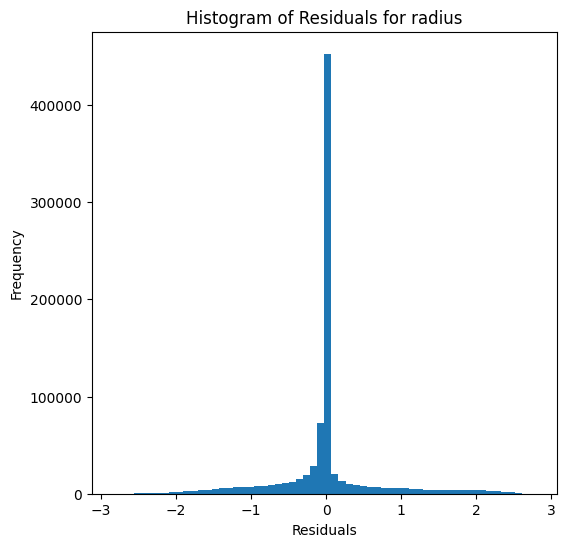

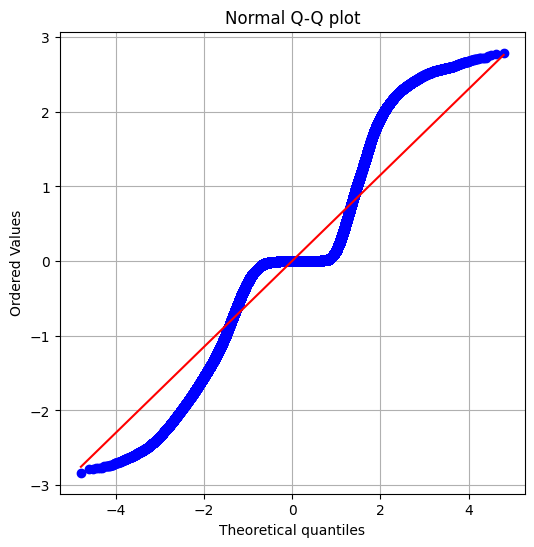

In [18]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, n_jobs=5) #, override=False, use_preds=True)

### XGBoost

In [19]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.804797760791325
RMSE :  0.15372881459782722
MAE :  0.11018247339752622
MedAE :  0.07680868913660222
CORR :  0.8971787896330891
MAX_ER :  0.8230129660359036
Percentiles : 
  75th percentile :  0.15375899739563526
  90th percentile :  0.2673260140074035
  95th percentile :  0.3396779592091909
  99th percentile :  0.46983361183647554



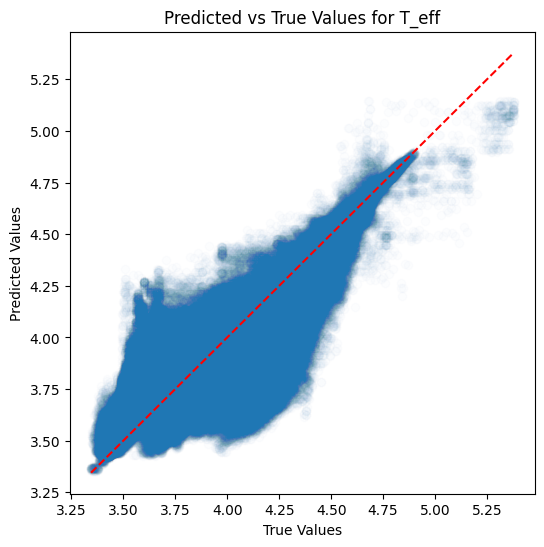

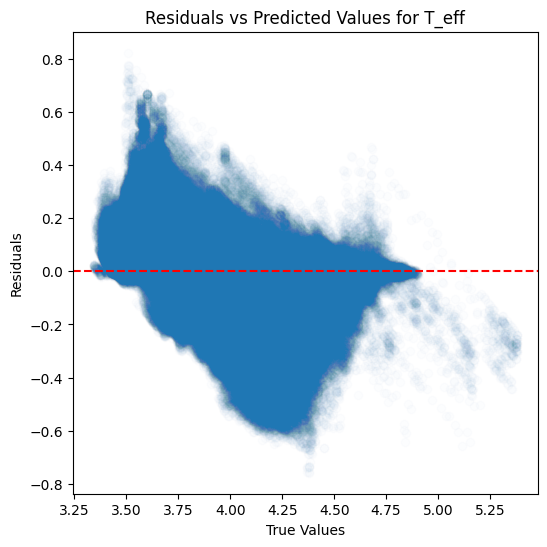

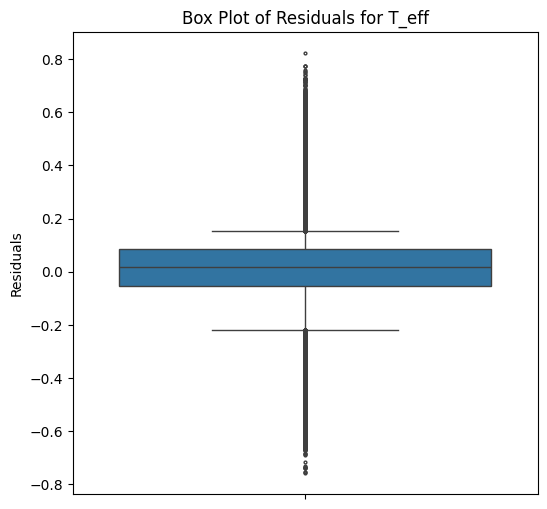

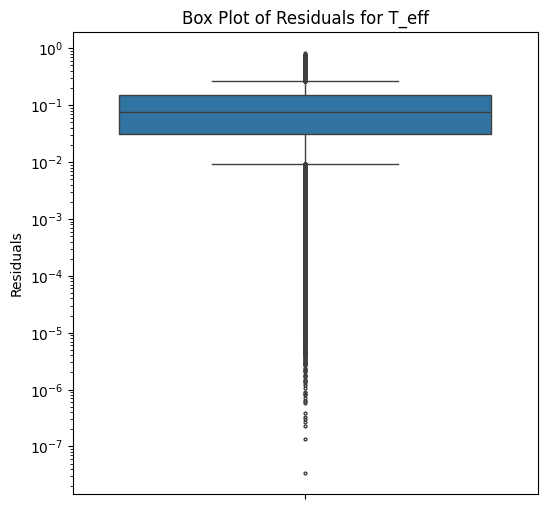

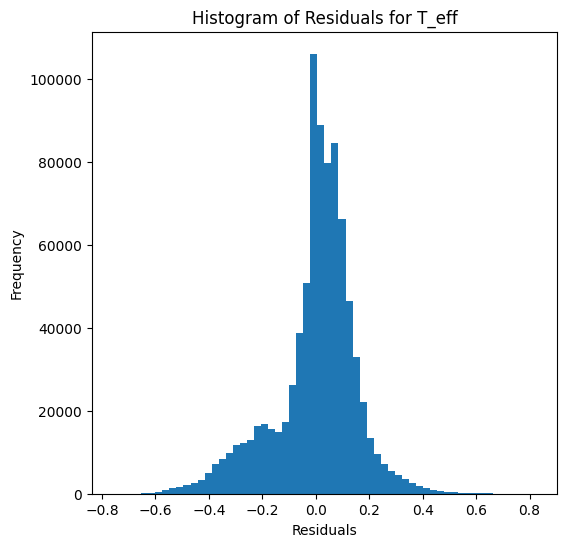

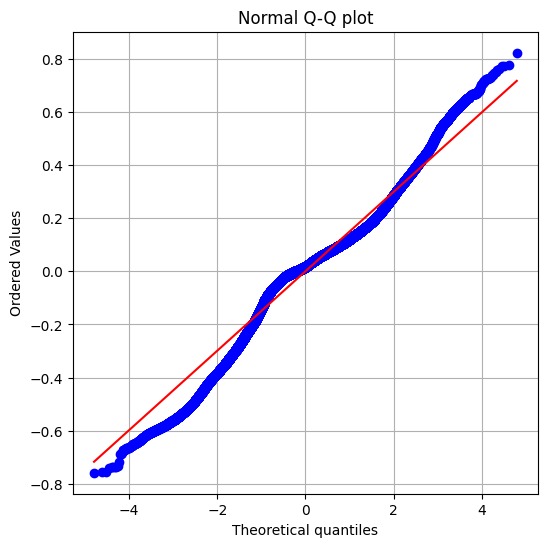


log_g results:
RVE :  0.5312956672239144
RMSE :  1.3042304973317753
MAE :  0.9705301270244092
MedAE :  0.7990194160494699
CORR :  0.7293538345597952
MAX_ER :  5.458209939654632
Percentiles : 
  75th percentile :  1.340811312583929
  90th percentile :  2.0947505526859462
  95th percentile :  2.856417988366912
  99th percentile :  3.9317966313365798



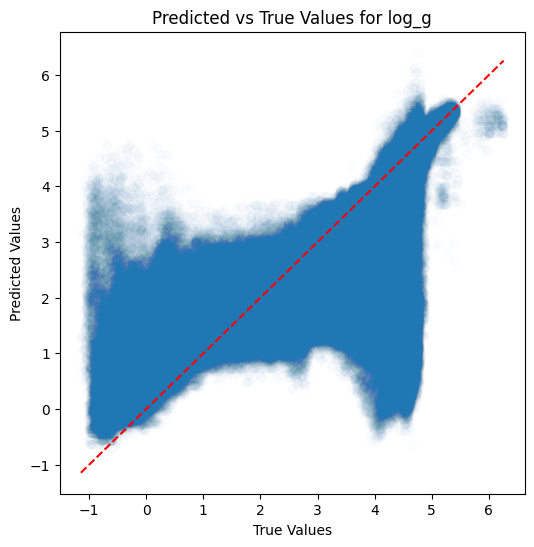

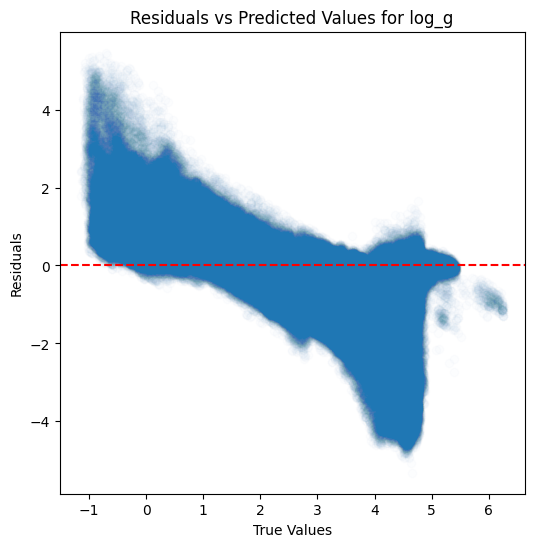

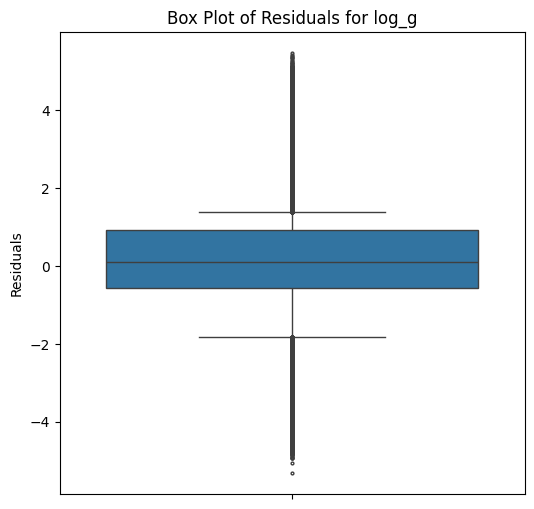

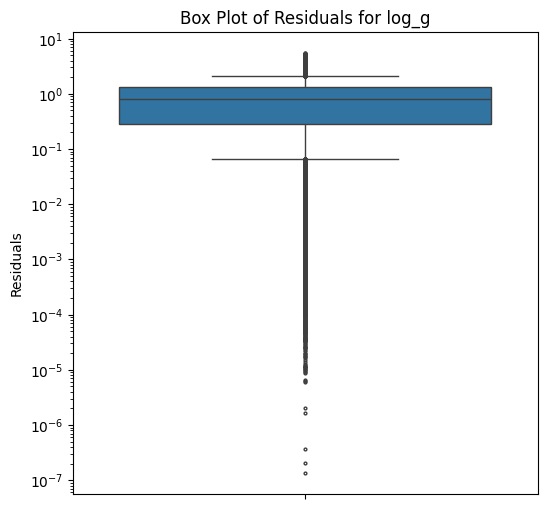

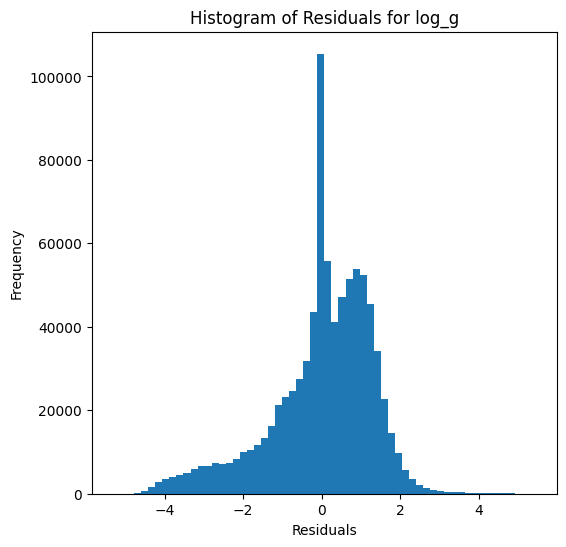

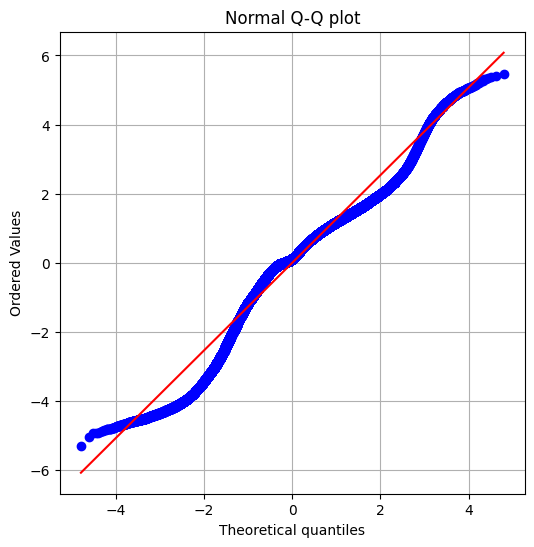


radius results:
RVE :  0.526839081428498
RMSE :  0.6538101106509971
MAE :  0.48770266379982125
MedAE :  0.40196506411056077
CORR :  0.7263148787946692
MAX_ER :  2.723048852466545
Percentiles : 
  75th percentile :  0.674251821248524
  90th percentile :  1.0514903350341938
  95th percentile :  1.4293256276006079
  99th percentile :  1.9647946296940562



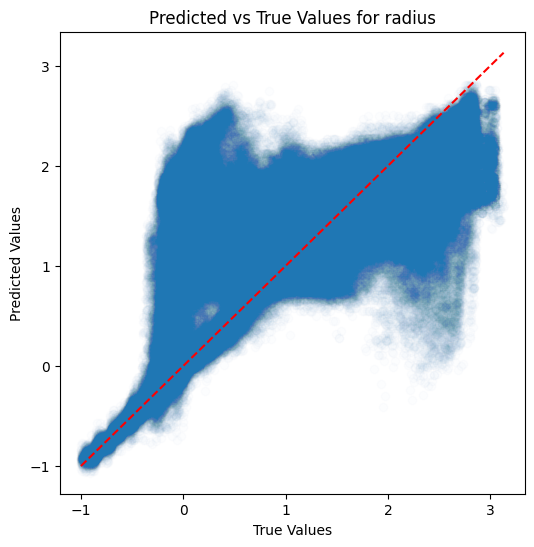

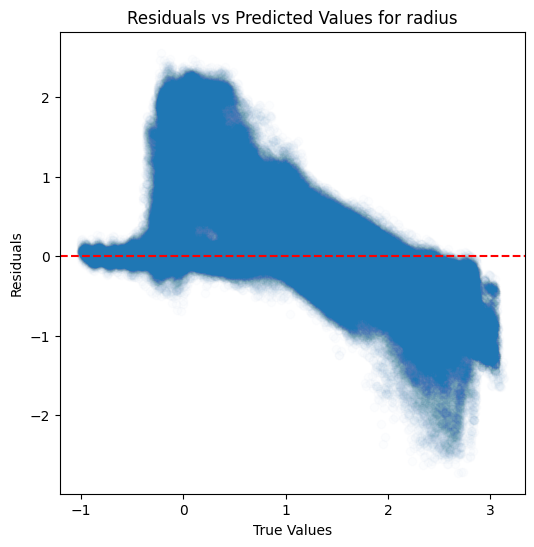

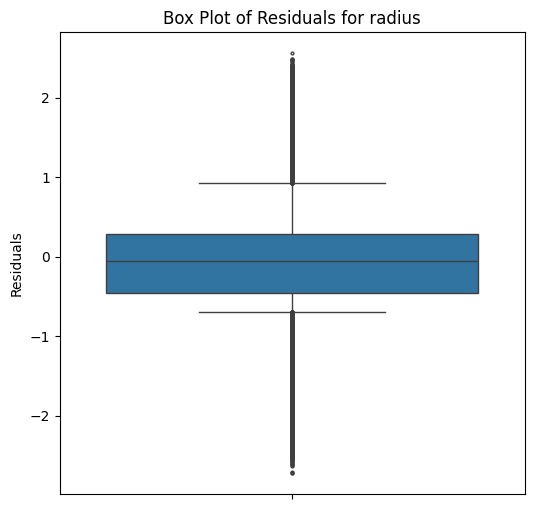

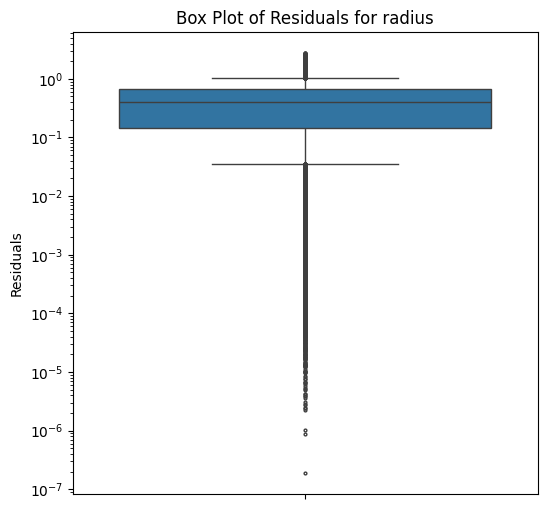

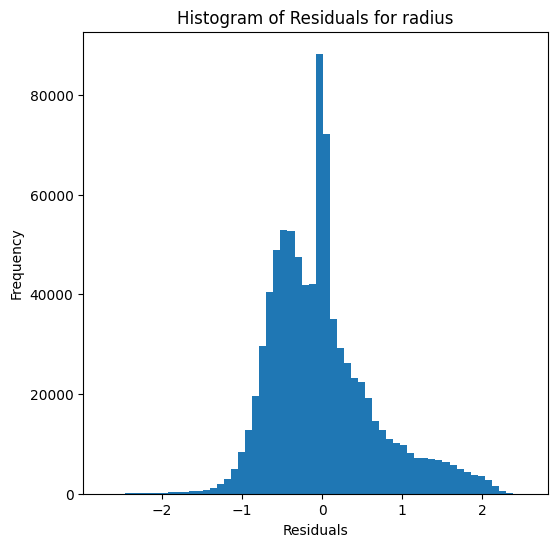

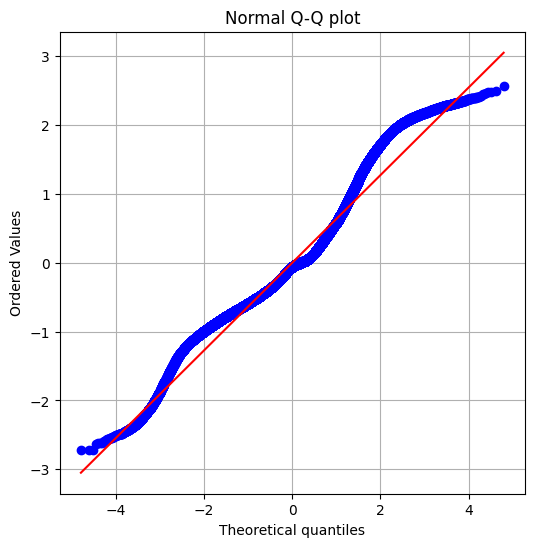

In [20]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, n_jobs=5) #, override=False, use_preds=True)

### Multi-layer perceptron

In [21]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.38630660553876134
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.38140156681083903
3 

...

0.38375343999983647
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.38207838264493216
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.3862618041031176

T_eff results:
RVE :  0.7551429651355984
RMSE :  0.1726177072051973
MAE :  0.12406645465245912
MedAE :  0.0819169534688422
CORR :  0.869060611486785
MAX_ER :  0.9886285722858914
Percentiles : 
  75th percentile :  0.1743844893627824
  90th percentile :  0.2997794154599709
  95th percentile :  0.37770851674105355
  99th percentile :  0.5316935948030879



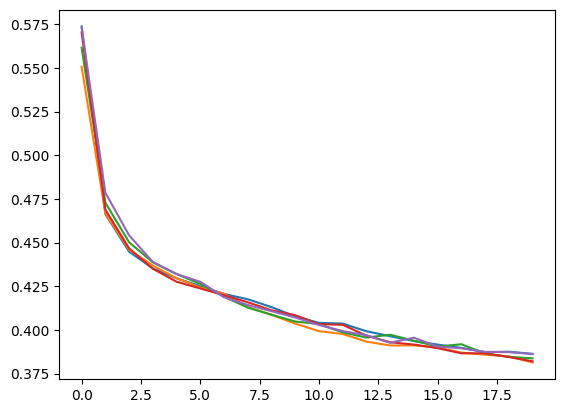

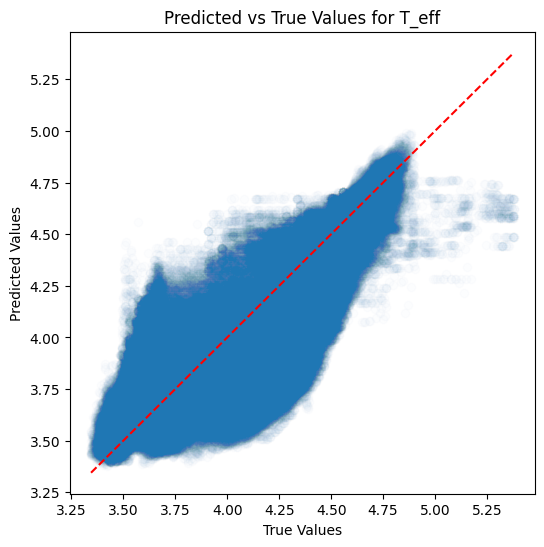

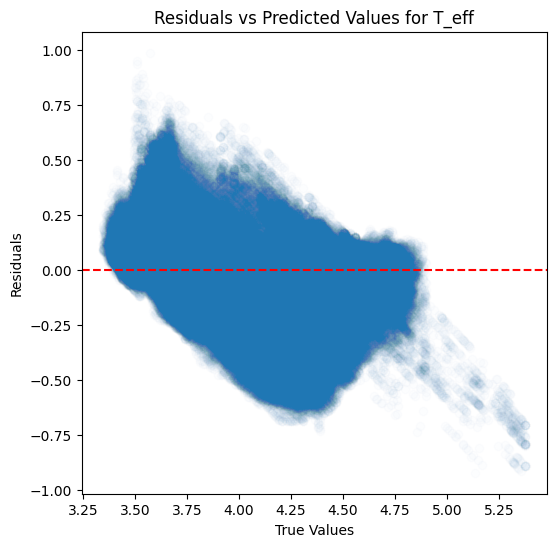

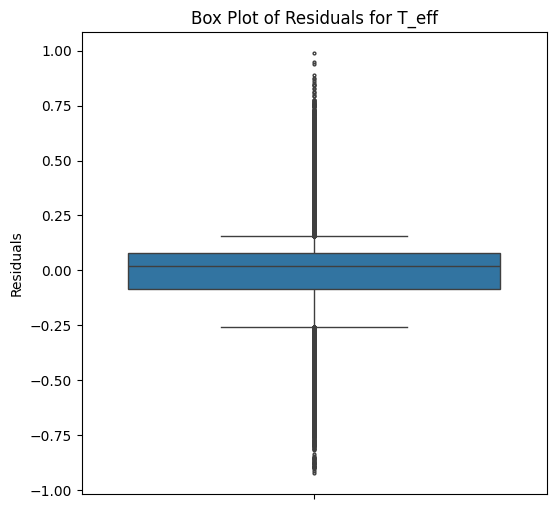

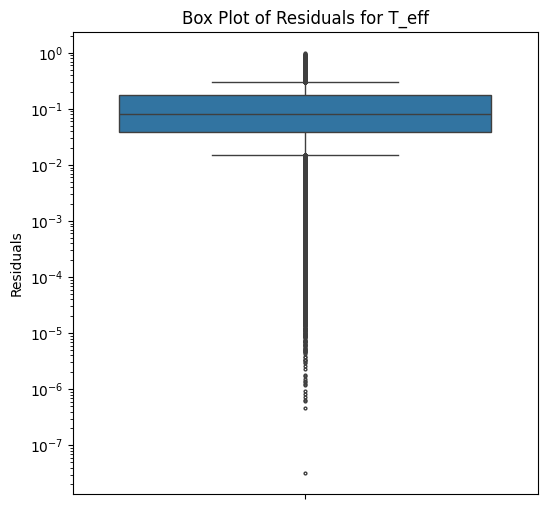

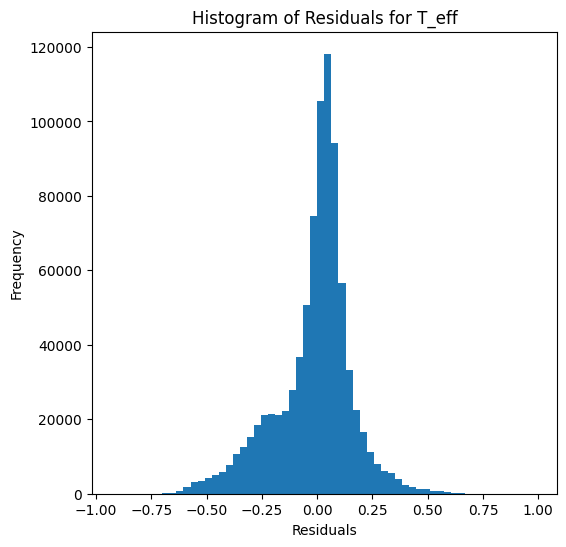

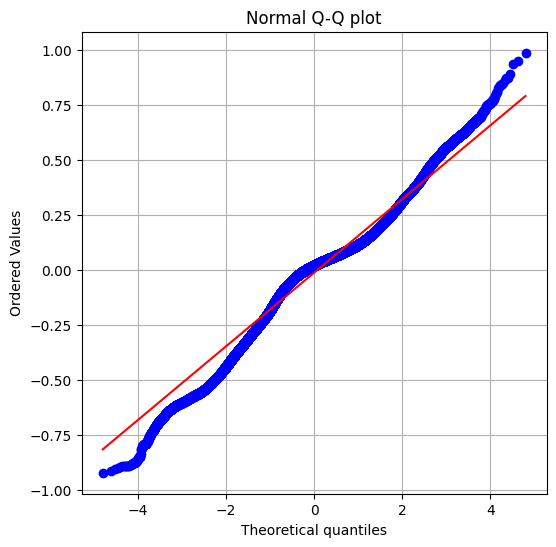


log_g results:
RVE :  0.48662467638832796
RMSE :  1.3668106268859745
MAE :  1.0198702265201651
MedAE :  0.8173303997437491
CORR :  0.6976524144656314
MAX_ER :  5.720480151825908
Percentiles : 
  75th percentile :  1.41537669278572
  90th percentile :  2.2465919979951137
  95th percentile :  2.988487809382097
  99th percentile :  4.025129168094562



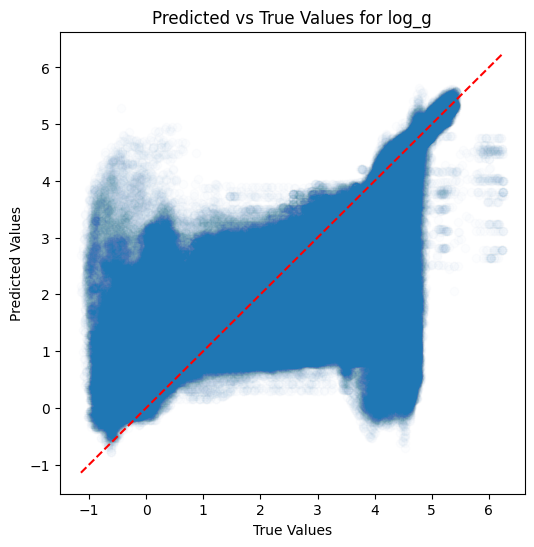

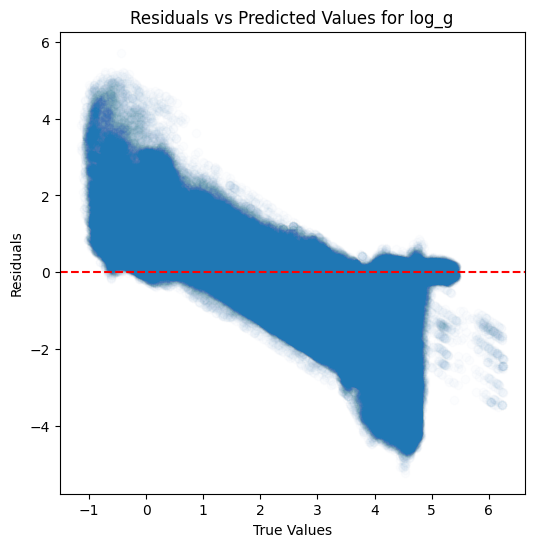

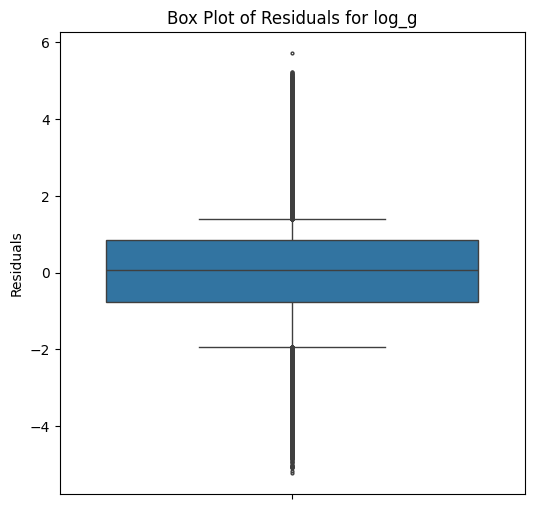

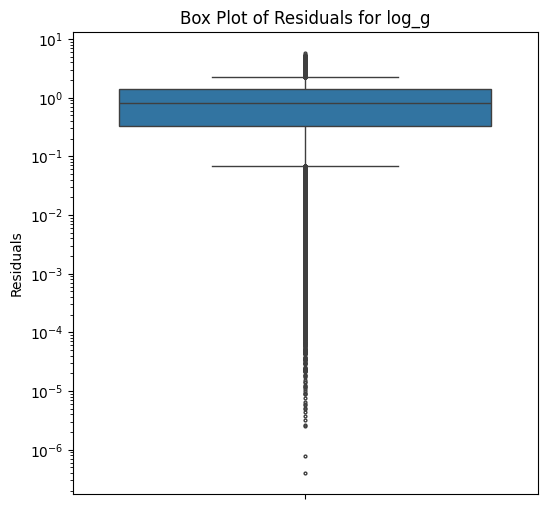

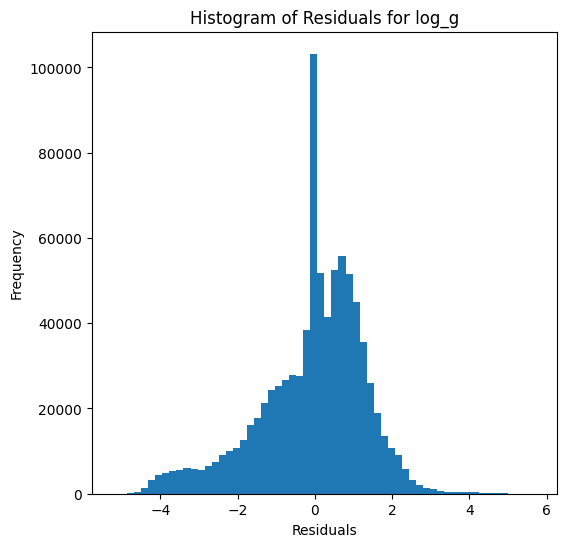

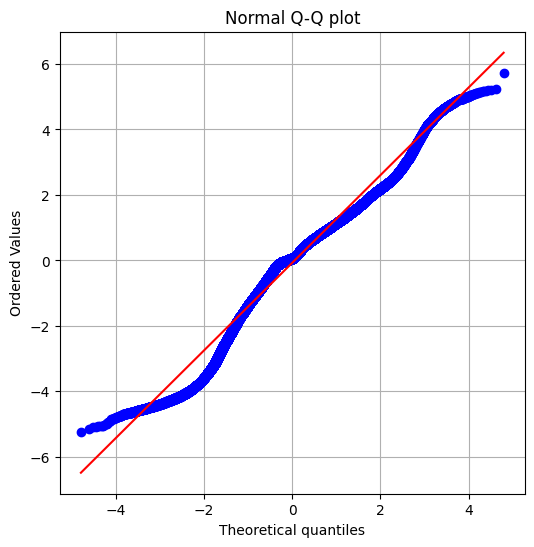


radius results:
RVE :  0.48321681900249447
RMSE :  0.684482145772477
MAE :  0.5115383743983661
MedAE :  0.40714371171101504
CORR :  0.6954592978831675
MAX_ER :  2.8867654378725236
Percentiles : 
  75th percentile :  0.7084463433500444
  90th percentile :  1.1231463658253484
  95th percentile :  1.4963742085704064
  99th percentile :  2.0207025103814202



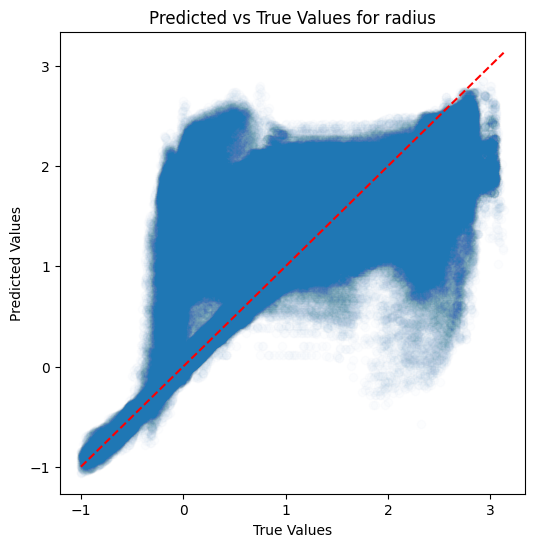

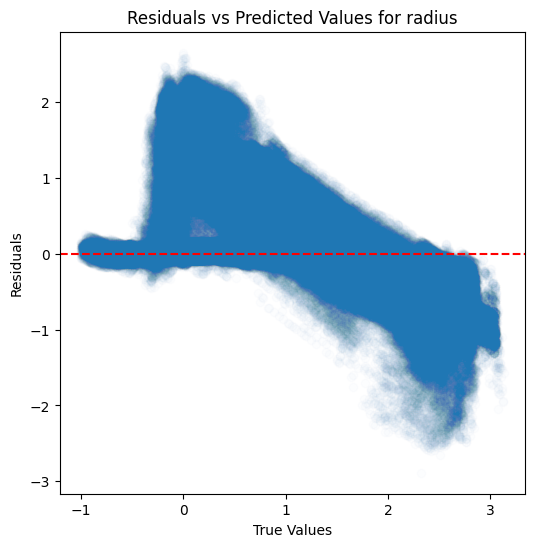

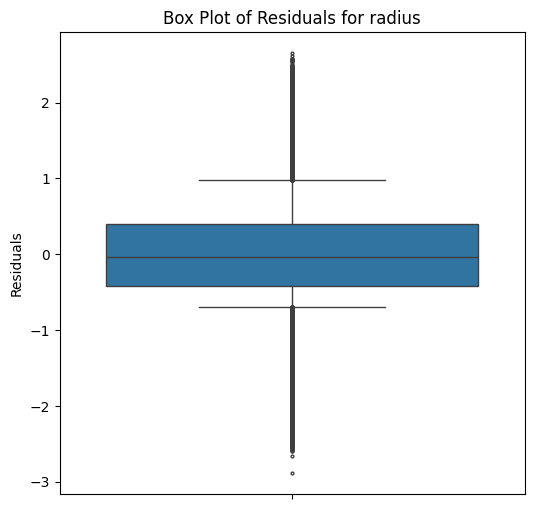

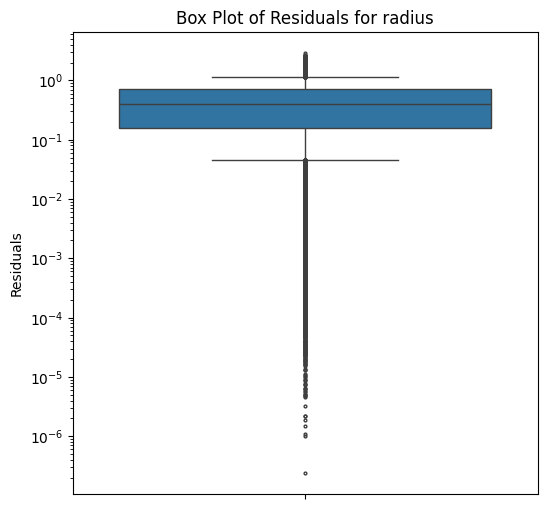

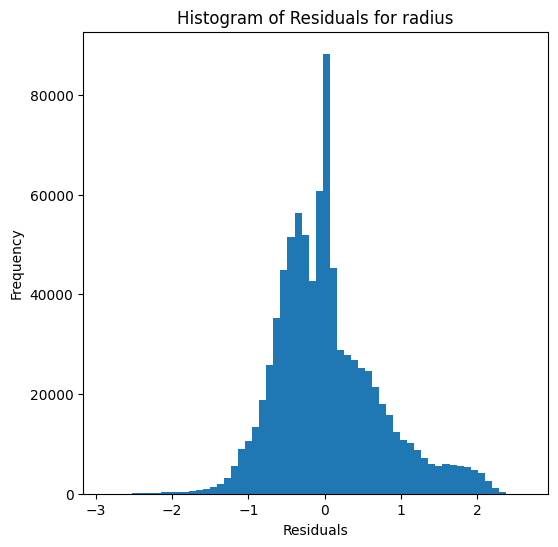

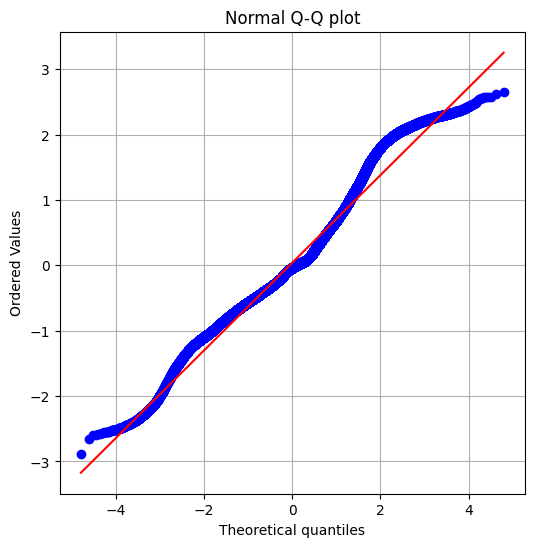

In [24]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, path_to_predictions, tag, n_splits=5, random_state=12, override=True, use_preds=False, hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon